# Notebook 04 — Pump Price Prediction: Modeling

**Philippine Weekly Diesel Pump Price — NCR, 2018–2026**

### References
- Lunor, S.B.R. et al. (2023). Machine Learning Approach for Pump Price Prediction for the Philippines Post COVID-19. *Chemical Engineering Transactions*, 103, 265–270.
- Lu, H. et al. (2021). Energy price prediction using data-driven models: A decade review. *Computer Science Review*, 39, 100356.
- Wen, D. et al. (2025). Forecasting gasoline prices: New evidence based on the rocket and feather hypothesis. *Energy*, 335.
- Hyndman, R.J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*, 3rd ed. OTexts.
- Borenstein, S., Cameron, A.C., & Gilbert, R. (1997). Do Gasoline Prices Respond Asymmetrically to Crude Oil Price Changes? *Quarterly Journal of Economics*, 112(1), 305–339.
- Hamilton, J.D. (1989). A New Approach to the Economic Analysis of Nonstationary Time Series. *Econometrica*, 57(2), 357–384.

---

## Introduction and Strategy

### Modeling target: log return, not price level

All models predict the log return:

$$r_t = \Delta\log p_t = \log\left(\frac{p_t}{p_{t-1}}\right)$$

Predictions are back-transformed to peso levels:

$$\hat{p}_t = p_{t-1} \cdot \exp(\hat{r}_t)$$

This is a one-step-ahead (h = 1) forecast. Each prediction uses features lagged ≥ 1 week and the observed $p_{t-1}$ for back-transformation. Predictions are not chained.

### Validation strategy

1. **Walk-forward expanding window CV** via `TimeSeriesSplit(n_splits=5)` for hyperparameter selection. Scalers and PCA are fitted inside each fold's training partition only.
2. **Fixed chronological holdout**: last 52 weeks as the test set, never touched during CV.

### Models

| # | Model | Type | Tuned hyperparameter |
|---|---|---|---|
| B1 | Naive lag-1 | Baseline | — |
| 1 | Ridge | Linear (L2) | α |
| 2 | Lasso | Linear (L1) | α |
| 3 | ElasticNet | Linear (L1+L2) | α |
| 4 | SVR (RBF) | Kernel | C |
| 5 | Random Forest | Tree ensemble | max_depth |
| 6 | Gradient Boosting | Additive trees | n_estimators |
| 7 | XGBoost | Regularised boosting | n_estimators |

### Primary metric

**MAPE on back-transformed ₱/L levels** (Lu et al. 2021; Lunor et al. 2023). Benchmark: 3.13%–12.67% (Lunor et al. 2023).

---
## Section 1 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (mean_absolute_percentage_error,
                              mean_absolute_error, mean_squared_error, r2_score)
import xgboost as xgb

os.makedirs('data/final', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# Single consistent style — no per-call fontsize or fontweight overrides
plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'figure.dpi':        100,
    'font.size':         10,
})

def fmt_xaxis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

# ── Metric helpers ─────────────────────────────────────────────────────────
def mape(y_true, y_pred):
    return mean_absolute_percentage_error(np.array(y_true), np.array(y_pred)) * 100

def directional_accuracy(y_true_ret, y_pred_ret):
    """% of weeks where sign(Δprice) is correctly predicted."""
    return (np.sign(y_true_ret) == np.sign(y_pred_ret)).mean() * 100

def evaluate(name, y_true_ret, y_pred_ret, price_prev, y_true_level):
    """Full metric suite. All level metrics on back-transformed ₱/L."""
    y_pred_level = price_prev * np.exp(y_pred_ret)
    return {
        'model':        name,
        'MAPE_%':       mape(y_true_level, y_pred_level),
        'MAE_php':      mean_absolute_error(y_true_level, y_pred_level),
        'RMSE_ret':     np.sqrt(mean_squared_error(y_true_ret, y_pred_ret)),
        'R2_ret':       r2_score(y_true_ret, y_pred_ret),
        'R2_level':     r2_score(y_true_level, y_pred_level),
        'DirAcc_%':     directional_accuracy(y_true_ret, y_pred_ret),
        'y_pred_level': y_pred_level,
    }

print('Setup complete. XGBoost:', xgb.__version__)

Setup complete. XGBoost: 3.2.0


---
## Section 2 — Load Feature Matrix

In [2]:
df = pd.read_parquet('data/final/features_engineered.parquet')
with open('data/final/feature_sets.json') as fh:
    feat_cfg = json.load(fh)['diesel']

DIRECT_FEATURES = feat_cfg['direct_features']
CRUDE_PCA_BLOCK = feat_cfg['crude_pca_block']
VOL_PCA_BLOCK   = feat_cfg['vol_pca_block']
GPR_PCA_BLOCK   = feat_cfg['gpr_pca_block']
N_CRUDE_COMP    = feat_cfg['n_crude_components']
N_VOL_COMP      = feat_cfg['n_vol_components']
N_GPR_COMP      = feat_cfg['n_gpr_components']
TARGET          = feat_cfg['target']        # 'diesel_log_ret'
LEVEL_ANCHOR    = feat_cfg['level_anchor']  # 'diesel'

all_needed = (DIRECT_FEATURES + CRUDE_PCA_BLOCK +
              VOL_PCA_BLOCK + GPR_PCA_BLOCK + [TARGET, LEVEL_ANCHOR])
missing = [c for c in all_needed if c not in df.columns]
if missing:
    print(f'WARNING: {len(missing)} columns missing: {missing}')
else:
    print('All required columns present.')

df_model = df[list(dict.fromkeys(all_needed))].copy()
df_model = df_model.dropna(subset=[TARGET])

print(f'Shape     : {df_model.shape}')
print(f'Dates     : {df_model.index.min().date()}  →  {df_model.index.max().date()}')
print(f'Target    : {TARGET}')
print(f'Features  : {len(DIRECT_FEATURES)} direct + '
      f'{len(CRUDE_PCA_BLOCK)}→{N_CRUDE_COMP} crude + '
      f'{len(VOL_PCA_BLOCK)}→{N_VOL_COMP} vol + '
      f'{len(GPR_PCA_BLOCK)}→{N_GPR_COMP} GPR  = '
      f'{len(DIRECT_FEATURES)+N_CRUDE_COMP+N_VOL_COMP+N_GPR_COMP} total model features')
print()
print('Direct features:')
for f in DIRECT_FEATURES:
    print(f'  {f}')

All required columns present.
Shape     : (368, 81)
Dates     : 2018-05-08  →  2026-04-28
Target    : diesel_log_ret
Features  : 51 direct + 12→5 crude + 12→6 vol + 16→7 GPR  = 69 total model features

Direct features:
  diesel_log_ret_lag1
  diesel_log_ret_lag2
  diesel_log_ret_lag3
  diesel_log_ret_lag4
  d_covid_lag1
  d_ukraine_lag1
  d_iran26_lag1
  brent_chg_pos_lag1
  brent_chg_pos_lag2
  brent_chg_pos_lag3
  brent_chg_pos_lag4
  brent_chg_neg_lag1
  brent_chg_neg_lag2
  brent_chg_neg_lag3
  brent_chg_neg_lag4
  brent_log_ret_lag1
  brent_pct_1w_lag1
  brent_php_log_ret_lag1
  diesel_mom_1w_lag1
  diesel_mom_2w_lag1
  GPR_OIL_lag1
  usdphp_pct_1w_lag1
  cpi_yoy_lag1
  crack_spread_lag1
  brent_log_ret_lag2
  brent_log_ret_lag3
  brent_log_ret_lag4
  brent_pct_1w_lag2
  brent_pct_1w_lag3
  brent_pct_1w_lag4
  brent_php_log_ret_lag2
  brent_php_log_ret_lag3
  brent_php_log_ret_lag4
  diesel_mom_1w_lag2
  diesel_mom_1w_lag3
  diesel_mom_1w_lag4
  diesel_mom_2w_lag2
  diesel_mom_2w_

---
## Section 3 — Feature Matrix Construction

Scalers and PCA are always fitted on the training partition and applied to the test partition — never fitted on pooled data.

In [3]:
def build_feature_matrix(df_sub, crude_block, vol_block, gpr_block,
                         direct_feats, n_crude, n_vol, n_gpr,
                         crude_scaler=None, crude_pca=None,
                         vol_scaler=None,   vol_pca=None,
                         gpr_scaler=None,   gpr_pca=None,
                         fit=False):
    """
    Assemble (n_samples × n_features) matrix.
    fit=True  → fit new scalers/PCAs on this subset (training partition).
    fit=False → apply pre-fitted objects (test/CV-test partition).
    """
    def _clean(X):
        df_tmp = pd.DataFrame(X).ffill().bfill().fillna(0)
        return df_tmp.values.astype(float)

    X_direct = _clean(df_sub[direct_feats].values)

    def _pca_block(block_cols, n_comp, scaler, pca_obj, fit_now):
        valid = [c for c in block_cols if c in df_sub.columns]
        Xb    = _clean(df_sub[valid].values)
        if fit_now:
            scaler  = StandardScaler()
            pca_obj = PCA(n_components=n_comp)
            Xs      = scaler.fit_transform(Xb)
            Xp      = pca_obj.fit_transform(Xs)
        else:
            Xs = scaler.transform(Xb)
            Xp = pca_obj.transform(Xs)
        return Xp, scaler, pca_obj

    Xc, crude_scaler, crude_pca = _pca_block(crude_block, n_crude, crude_scaler, crude_pca, fit)
    Xv, vol_scaler,   vol_pca   = _pca_block(vol_block,   n_vol,   vol_scaler,   vol_pca,   fit)
    Xg, gpr_scaler,   gpr_pca   = _pca_block(gpr_block,   n_gpr,   gpr_scaler,   gpr_pca,   fit)

    X_out = np.hstack([X_direct, Xc, Xv, Xg])
    assert not np.isnan(X_out).any(), (
        f'NaN in build_feature_matrix output: {np.isnan(X_out).sum()} values')

    if fit:
        return X_out, crude_scaler, crude_pca, vol_scaler, vol_pca, gpr_scaler, gpr_pca
    return X_out

print('build_feature_matrix() defined.')

build_feature_matrix() defined.


---
## Section 4 — Train / Test Split

The last 52 weeks form the chronological holdout test set. The plot shows the full price history so the model's context is clear: training spans the COVID dip and the 2022 energy shock; the test period begins in April 2025 and runs through the 2026 price spike — the most extreme out-of-distribution event in the sample.

In [4]:
TEST_WEEKS = 52
split_idx  = len(df_model) - TEST_WEEKS

df_train = df_model.iloc[:split_idx]
df_test  = df_model.iloc[split_idx:]

y_train = df_train[TARGET].values
y_test  = df_test[TARGET].values

price_level_all  = df_model[LEVEL_ANCHOR]
price_prev_train = price_level_all.shift(1).iloc[:split_idx].values
price_prev_test  = price_level_all.shift(1).iloc[split_idx:].values
y_test_level     = price_level_all.iloc[split_idx:].values

print(f'Training : {len(df_train)} weeks  ({df_train.index.min().date()} → {df_train.index.max().date()})')
print(f'Test     : {len(df_test)}  weeks  ({df_test.index.min().date()}  → {df_test.index.max().date()})')
print()
print(f'Test price: mean=₱{y_test_level.mean():.2f}  min=₱{y_test_level.min():.2f}  max=₱{y_test_level.max():.2f}')
print(f'Training max = ₱{df_train[LEVEL_ANCHOR].max():.2f}/L')
print(f'Test max exceeds training max by {(y_test_level.max()/df_train[LEVEL_ANCHOR].max()-1)*100:.1f}%')

Training : 316 weeks  (2018-05-08 → 2025-04-15)
Test     : 52  weeks  (2025-04-22  → 2026-04-28)

Test price: mean=₱64.48  min=₱51.03  max=₱147.80
Training max = ₱90.18/L
Test max exceeds training max by 63.9%


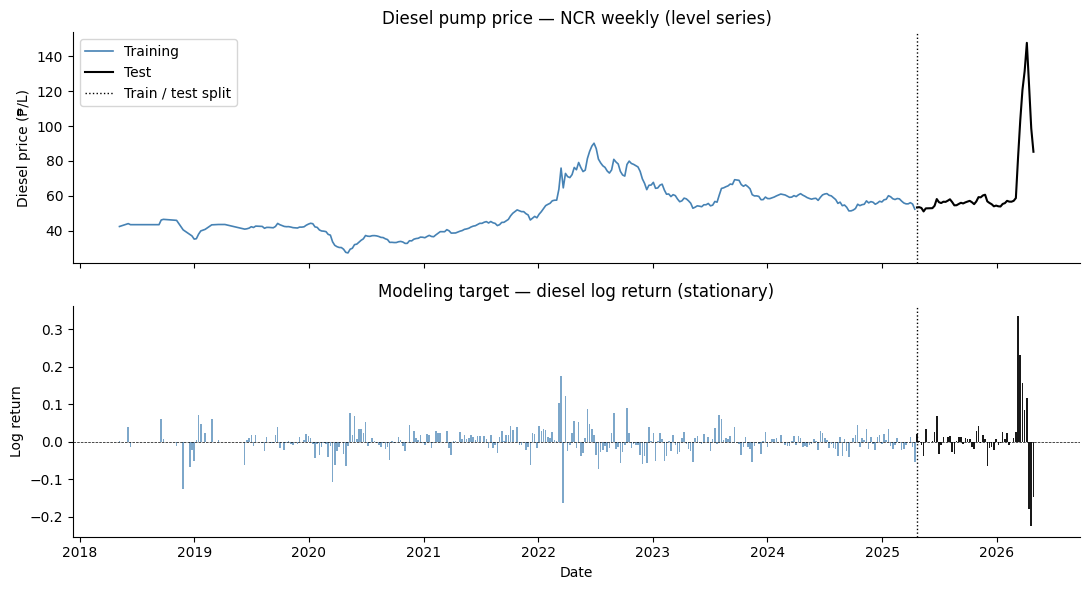

In [5]:
# The story: prices trended up from 2019, crashed in COVID, recovered, spiked with Russia-Ukraine,
# stabilised, then surged again in 2026. The log return panel shows the model's actual target
# is a stationary, zero-mean series — the 2026 spike appears as a cluster of large positive returns.

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
fig.subplots_adjust(hspace=0.1)

# Panel 1: price level
ax = axes[0]
ax.plot(df_train.index, df_train[LEVEL_ANCHOR], color='steelblue', linewidth=1.2,
        label='Training')
ax.plot(df_test.index,  y_test_level,            color='black',    linewidth=1.5,
        label='Test')
ax.axvline(df_test.index[0], color='black', linestyle=':', linewidth=1.0,
           label='Train / test split')
ax.set_ylabel('Diesel price (₱/L)')
ax.set_title('Diesel pump price — NCR weekly (level series)')
ax.legend(loc='upper left')
fmt_xaxis(ax)

# Panel 2: log return — the modeling target
ax2 = axes[1]
ax2.bar(df_train.index, df_train[TARGET], color='steelblue', width=5, alpha=0.7)
ax2.bar(df_test.index,  y_test,           color='black',     width=5, alpha=0.9)
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.axvline(df_test.index[0], color='black', linestyle=':', linewidth=1.0)
ax2.set_ylabel('Log return')
ax2.set_xlabel('Date')
ax2.set_title('Modeling target — diesel log return (stationary)')
fmt_xaxis(ax2)

plt.tight_layout()
plt.savefig('outputs/04_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
(X_train, crude_scaler, crude_pca,
          vol_scaler,   vol_pca,
          gpr_scaler,   gpr_pca) = build_feature_matrix(
    df_train, CRUDE_PCA_BLOCK, VOL_PCA_BLOCK, GPR_PCA_BLOCK,
    DIRECT_FEATURES, N_CRUDE_COMP, N_VOL_COMP, N_GPR_COMP, fit=True)

X_test = build_feature_matrix(
    df_test, CRUDE_PCA_BLOCK, VOL_PCA_BLOCK, GPR_PCA_BLOCK,
    DIRECT_FEATURES, N_CRUDE_COMP, N_VOL_COMP, N_GPR_COMP,
    crude_scaler=crude_scaler, crude_pca=crude_pca,
    vol_scaler=vol_scaler,     vol_pca=vol_pca,
    gpr_scaler=gpr_scaler,     gpr_pca=gpr_pca, fit=False)

dir_scaler    = StandardScaler()
n_direct      = len(DIRECT_FEATURES)
X_train_final = np.hstack([dir_scaler.fit_transform(X_train[:, :n_direct]), X_train[:, n_direct:]])
X_test_final  = np.hstack([dir_scaler.transform(X_test[:,  :n_direct]),     X_test[:,  n_direct:]])

assert not np.isnan(X_train_final).any(), 'X_train_final has NaN'
assert not np.isnan(X_test_final).any(),  'X_test_final has NaN'

print(f'X_train_final : {X_train_final.shape}  NaN: {np.isnan(X_train_final).sum()}')
print(f'X_test_final  : {X_test_final.shape}   NaN: {np.isnan(X_test_final).sum()}')

FEAT_NAMES = (DIRECT_FEATURES +
              [f'crude_PC{i+1}' for i in range(N_CRUDE_COMP)] +
              [f'vol_PC{i+1}'   for i in range(N_VOL_COMP)] +
              [f'gpr_PC{i+1}'   for i in range(N_GPR_COMP)])

X_train_final : (316, 69)  NaN: 0
X_test_final  : (52, 69)   NaN: 0


---
## Section 5 — Walk-Forward CV and Visualization Helpers

In [7]:
def tscv_score_model(model_fn, param_list, df_tr,
                     crude_block, vol_block, gpr_block,
                     direct_feats, n_crude, n_vol, n_gpr,
                     target, n_splits=5):
    """
    Walk-forward hyperparameter sweep.
    Scalers and PCA re-fitted on each fold's training partition.
    Returns all_train, all_test: DataFrames (n_params × n_folds).
    """
    tscv      = TimeSeriesSplit(n_splits=n_splits)
    all_train = pd.DataFrame()
    all_test  = pd.DataFrame()
    y_all = df_tr[target].values
    idx   = np.arange(len(df_tr))

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(idx)):
        df_fold_tr = df_tr.iloc[tr_idx]
        df_fold_te = df_tr.iloc[te_idx]
        y_fold_tr  = y_all[tr_idx]
        y_fold_te  = y_all[te_idx]

        (Xf_tr, cs, cp, vs, vp, gs, gp) = build_feature_matrix(
            df_fold_tr, crude_block, vol_block, gpr_block,
            direct_feats, n_crude, n_vol, n_gpr, fit=True)
        Xf_te = build_feature_matrix(
            df_fold_te, crude_block, vol_block, gpr_block,
            direct_feats, n_crude, n_vol, n_gpr,
            crude_scaler=cs, crude_pca=cp,
            vol_scaler=vs,   vol_pca=vp,
            gpr_scaler=gs,   gpr_pca=gp, fit=False)

        ds    = StandardScaler()
        nd    = len(direct_feats)
        Xf_tr = np.hstack([ds.fit_transform(Xf_tr[:, :nd]), Xf_tr[:, nd:]])
        Xf_te = np.hstack([ds.transform(Xf_te[:, :nd]),     Xf_te[:, nd:]])

        tr_sc, te_sc = [], []
        for param in param_list:
            reg = model_fn(param)
            reg.fit(Xf_tr, y_fold_tr)
            tr_sc.append(reg.score(Xf_tr, y_fold_tr))
            te_sc.append(reg.score(Xf_te, y_fold_te))
        all_train[fold] = tr_sc
        all_test[fold]  = te_sc

    return all_train, all_test


def plot_param_sweep(param_list, all_train, all_test, param_name, model_name, logscale=True):
    """Errorbar R² sweep: mean ± std across CV folds."""
    fig, ax = plt.subplots(figsize=(9, 3.5))
    if logscale:
        ax.set_xscale('log')

    ax.errorbar(param_list, all_train.mean(axis=1), yerr=all_train.std(axis=1),
                label='training R²', color='steelblue',
                marker='o', linestyle='dashed', markersize=7)
    ax.errorbar(param_list, all_test.mean(axis=1),  yerr=all_test.std(axis=1),
                label='CV test R²', color='#c0392b',
                marker='^', linestyle='-', markersize=7)
    ax.set_ylabel('R²')
    ax.set_xlabel(param_name)
    ax.set_title(f'{model_name} — R² vs {param_name}  (walk-forward CV, n_splits=5)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    best_idx = np.argmax(all_test.mean(axis=1))
    best_val = param_list[best_idx]
    print(f'Best CV R² = {all_test.mean(axis=1).iloc[best_idx]:.4f}  '
          f'(std = {all_test.std(axis=1).iloc[best_idx]:.4f})')
    print(f'Best {param_name} = {best_val}')
    return best_val


def plot_model(name, metrics, df_tr, df_te, level_col, pred_level, color, fname=None):
    """
    Two-panel per-model figure.

    Panel 1: Full-sample time series — training (light), test actual (black),
             test predicted (colored). The vertical split line separates what
             the model saw from what it was asked to predict.

    Panel 2: Actual vs predicted scatter. Points from the 2026 shock period
             are shown separately to make extrapolation failure visible.
    """
    fig = plt.figure(figsize=(11, 8))
    gs  = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[2.0, 1.0], hspace=0.32)

    # Panel 1: time series
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(df_tr.index, df_tr[level_col], color='#bbbbbb', linewidth=1.0,
             label='Training (observed)')
    ax1.plot(df_te.index, df_te[level_col], color='black', linewidth=1.5,
             label='Test (observed)')
    ax1.plot(df_te.index, pred_level, color=color, linewidth=1.4,
             linestyle='--', label=f'{name} (predicted)')
    ax1.axvline(df_te.index[0], color='black', linestyle=':', linewidth=1.0,
                label='Train / test split')
    fmt_xaxis(ax1)
    ax1.set_ylabel('Diesel price (₱/L)')
    ax1.set_title(
        f'{name}  |  MAPE={metrics["MAPE_%"]:.2f}%   '
        f'MAE=₱{metrics["MAE_php"]:.2f}/L   '
        f'DirAcc={metrics["DirAcc_%"]:.0f}%   '
        f'R²={metrics["R2_level"]:.3f}')
    ax1.legend(loc='upper left', ncol=2)

    # Panel 2: scatter
    ax2 = fig.add_subplot(gs[1])
    y_actual   = df_te[level_col].values
    shock_mask = df_te.index >= pd.Timestamp('2026-01-01')
    ax2.scatter(y_actual[~shock_mask], pred_level[~shock_mask],
                color='#555555', alpha=0.7, s=25, label='Stable period')
    ax2.scatter(y_actual[shock_mask],  pred_level[shock_mask],
                color='#c0392b', alpha=0.9, s=35, marker='D',
                label='2026 shock')
    lo = min(y_actual.min(), pred_level.min()) - 4
    hi = max(y_actual.max(), pred_level.max()) + 4
    ax2.plot([lo, hi], [lo, hi], 'k--', linewidth=1.0, label='Perfect prediction')
    ax2.set_xlim(lo, hi)
    ax2.set_ylim(lo, hi)
    ax2.set_xlabel('Actual (₱/L)')
    ax2.set_ylabel('Predicted (₱/L)')
    ax2.set_title('Actual vs predicted — test set')
    ax2.legend()

    plt.tight_layout()
    if fname:
        plt.savefig(f'outputs/{fname}', dpi=150, bbox_inches='tight')
    plt.show()


print('Helper functions defined.')

Helper functions defined.


---
## Section 6 — Baselines

The naive lag-1 baseline predicts $\hat{p}_t = p_{t-1}$ — next week's price is this week's price. It has deceptively low MAPE because pump prices move slowly. Any ML model that cannot beat this has no predictive value beyond copying the most recent price. Directional accuracy > 50% is the real test of whether a model has learned genuine signal.

In [8]:
naive_ret     = np.zeros(len(y_test))
naive_metrics = evaluate('Naive (lag-1)', y_test, naive_ret, price_prev_test, y_test_level)

print('Naive lag-1 baseline (test set):')
print(f'  MAPE         = {naive_metrics["MAPE_%"]:.4f}%')
print(f'  MAE          = ₱{naive_metrics["MAE_php"]:.4f}/L')
print(f'  DirAcc       = {naive_metrics["DirAcc_%"]:.1f}%  (50% = coin flip)')
print(f'  R² (levels)  = {naive_metrics["R2_level"]:.4f}')
print(f'  RMSE (ret)   = {naive_metrics["RMSE_ret"]:.6f}  ← equals std(log returns)')
print()
print('Any ML model must beat on:')
print('  ✓ MAPE < naive MAPE')
print('  ✓ DirAcc materially > 50%')
print('  ✓ RMSE on returns < naive RMSE')

plot_data = [('Naive (lag-1)', naive_metrics, '#888888')]

Naive lag-1 baseline (test set):
  MAPE         = 4.2348%
  MAE          = ₱3.7457/L
  DirAcc       = 0.0%  (50% = coin flip)
  R² (levels)  = 0.8739
  RMSE (ret)   = 0.080638  ← equals std(log returns)

Any ML model must beat on:
  ✓ MAPE < naive MAPE
  ✓ DirAcc materially > 50%
  ✓ RMSE on returns < naive RMSE


---
## Section 7 — Ridge Regression (L2)

$$\min_{\mathbf{w}} \|\mathbf{r} - X\mathbf{w}\|^2 + \alpha \|\mathbf{w}\|_2^2$$

Ridge shrinks coefficients toward zero without zeroing any out. It is the regularized extension of MLR — Lunor et al. (2023) used unregularized MLR; Ridge adds robustness for the lag feature space.

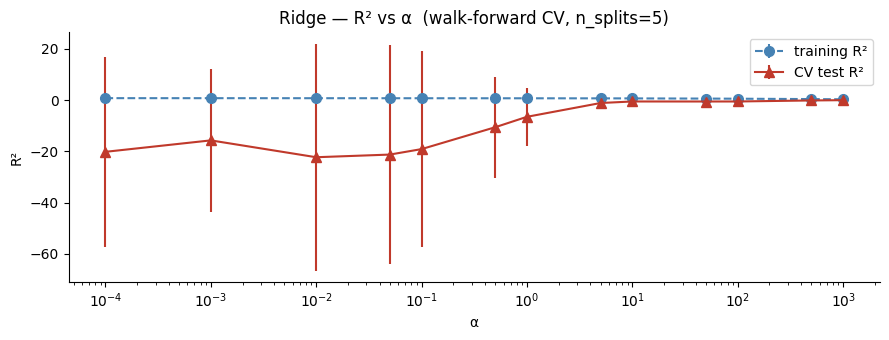

Best CV R² = -0.0253  (std = 0.4376)
Best α = 1000


In [9]:
alpha_ridge = [1e-4, 1e-3, 1e-2, 5e-2, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]

all_train_r, all_test_r = tscv_score_model(
    lambda a: Ridge(alpha=a), alpha_ridge, df_train,
    CRUDE_PCA_BLOCK, VOL_PCA_BLOCK, GPR_PCA_BLOCK,
    DIRECT_FEATURES, N_CRUDE_COMP, N_VOL_COMP, N_GPR_COMP, TARGET)

best_alpha_r = plot_param_sweep(alpha_ridge, all_train_r, all_test_r, 'α', 'Ridge')

Ridge (α = 1000)
  Train R²     = 0.3315
  Test  R²     = 0.1801
  MAPE (level) = 3.7305%
  MAE  (level) = ₱3.3416/L
  DirAcc       = 65.4%
  Beats naive? MAPE: True  DirAcc: True


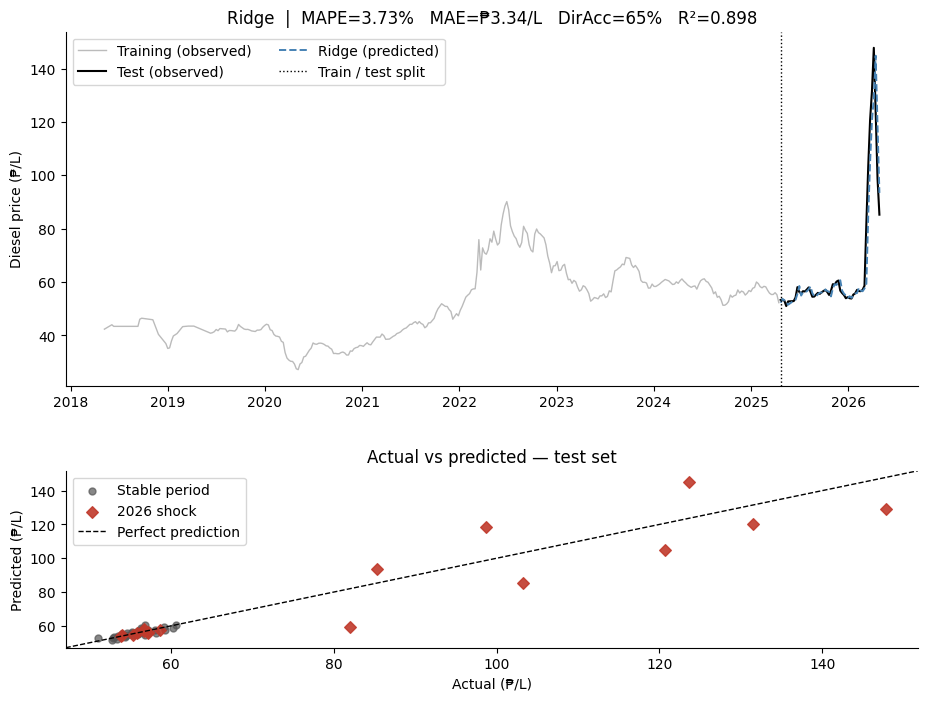

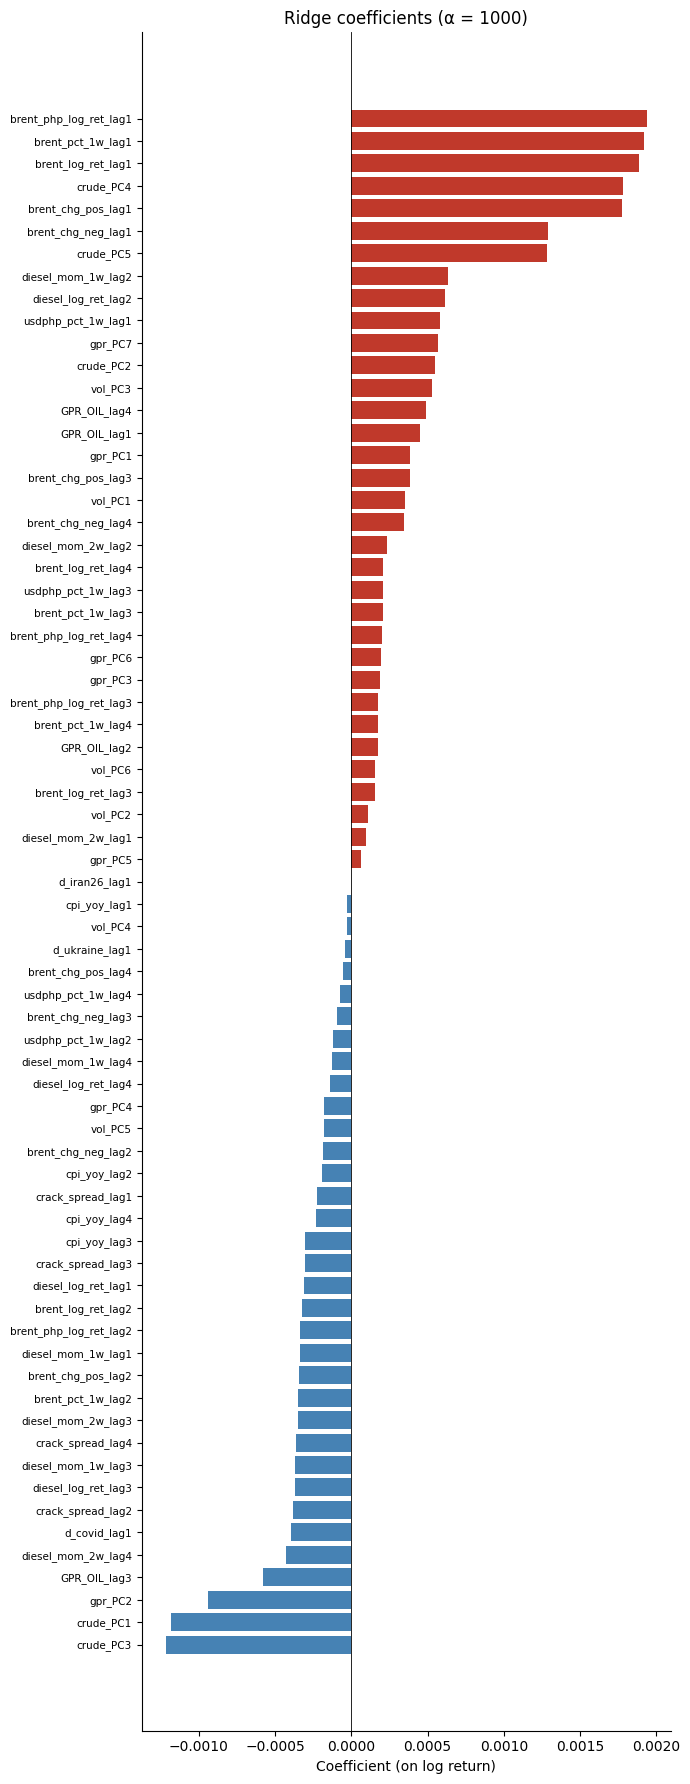

In [10]:
ridge_best   = Ridge(alpha=best_alpha_r).fit(X_train_final, y_train)
y_pred_r_ret = ridge_best.predict(X_test_final)
metrics_r    = evaluate('Ridge', y_test, y_pred_r_ret, price_prev_test, y_test_level)

print(f'Ridge (α = {best_alpha_r})')
print(f'  Train R²     = {ridge_best.score(X_train_final, y_train):.4f}')
print(f'  Test  R²     = {ridge_best.score(X_test_final,  y_test):.4f}')
print(f'  MAPE (level) = {metrics_r["MAPE_%"]:.4f}%')
print(f'  MAE  (level) = ₱{metrics_r["MAE_php"]:.4f}/L')
print(f'  DirAcc       = {metrics_r["DirAcc_%"]:.1f}%')
print(f'  Beats naive? MAPE: {metrics_r["MAPE_%"] < naive_metrics["MAPE_%"]}  '
      f'DirAcc: {metrics_r["DirAcc_%"] > 50}')

plot_model('Ridge', metrics_r, df_train, df_test,
           LEVEL_ANCHOR, metrics_r['y_pred_level'], 'steelblue', '04_ridge.png')
plot_data.append(('Ridge', metrics_r, 'steelblue'))

coef_s = pd.Series(ridge_best.coef_, index=FEAT_NAMES).sort_values()
fig, ax = plt.subplots(figsize=(7, max(4, len(coef_s)*0.26)))
colors  = ['#c0392b' if v > 0 else 'steelblue' for v in coef_s]
ax.barh(range(len(coef_s)), coef_s.values, color=colors, edgecolor='none')
ax.set_yticks(range(len(coef_s)))
ax.set_yticklabels(coef_s.index, fontsize=7.5)
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlabel('Coefficient (on log return)')
ax.set_title(f'Ridge coefficients (α = {best_alpha_r})')
plt.tight_layout()
plt.savefig('outputs/04_ridge_coef.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8 — Lasso Regression (L1)

$$\min_{\mathbf{w}} \|\mathbf{r} - X\mathbf{w}\|^2 + \alpha \|\mathbf{w}\|_1$$

Lasso zeros out coefficients, performing automatic feature selection. The surviving features answer which ones actually drive diesel log returns — a direct check on the feature engineering decisions from Notebook 03.

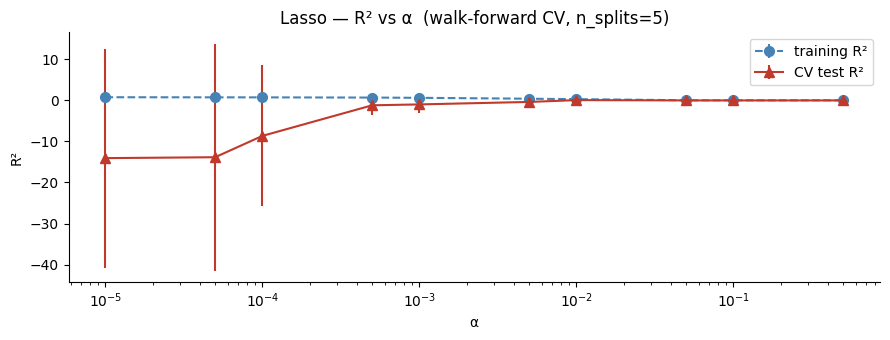

Best CV R² = 0.0401  (std = 0.1753)
Best α = 0.01


In [11]:
alpha_lasso = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 0.1, 0.5]

all_train_l, all_test_l = tscv_score_model(
    lambda a: Lasso(alpha=a, max_iter=100000), alpha_lasso, df_train,
    CRUDE_PCA_BLOCK, VOL_PCA_BLOCK, GPR_PCA_BLOCK,
    DIRECT_FEATURES, N_CRUDE_COMP, N_VOL_COMP, N_GPR_COMP, TARGET)

best_alpha_l = plot_param_sweep(alpha_lasso, all_train_l, all_test_l, 'α', 'Lasso')

Lasso (α = 0.01)
  Train R²         = 0.2094
  Test  R²         = 0.0826
  MAPE (level)     = 3.9662%
  Non-zero coefs   = 3 of 69
  DirAcc           = 69.2%


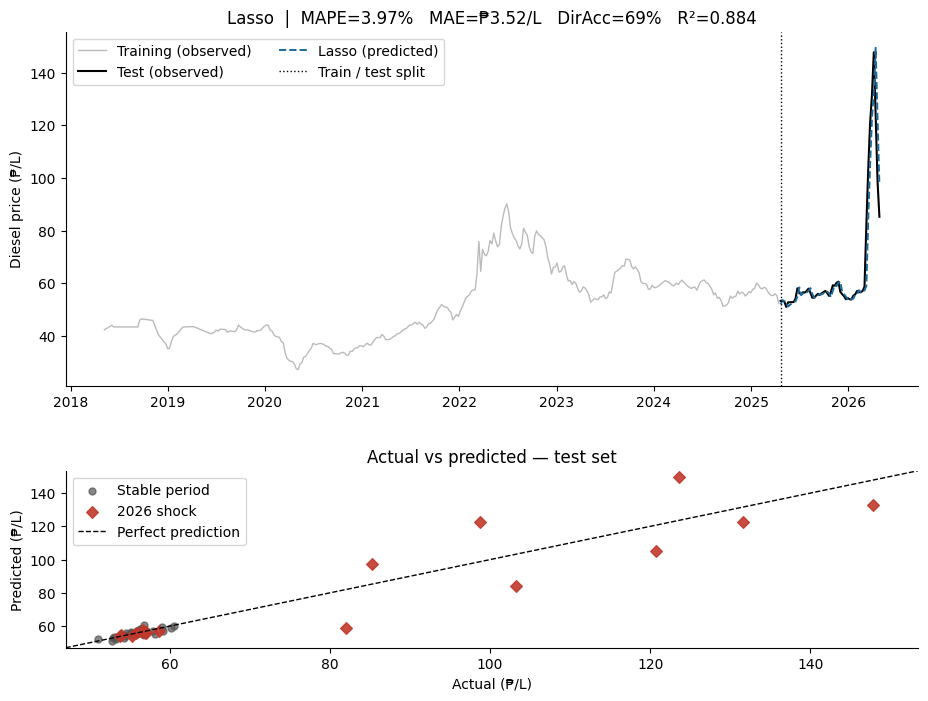

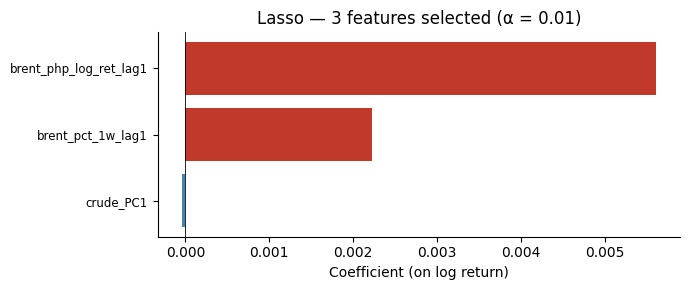

Selected features:
  ↑ brent_php_log_ret_lag1                    coef = 0.00561
  ↑ brent_pct_1w_lag1                         coef = 0.00222
  ↓ crude_PC1                                 coef = -0.00004


In [12]:
lasso_best   = Lasso(alpha=best_alpha_l, max_iter=100000).fit(X_train_final, y_train)
y_pred_l_ret = lasso_best.predict(X_test_final)
metrics_l    = evaluate('Lasso', y_test, y_pred_l_ret, price_prev_test, y_test_level)

n_nonzero = np.sum(lasso_best.coef_ != 0)
print(f'Lasso (α = {best_alpha_l})')
print(f'  Train R²         = {lasso_best.score(X_train_final, y_train):.4f}')
print(f'  Test  R²         = {lasso_best.score(X_test_final,  y_test):.4f}')
print(f'  MAPE (level)     = {metrics_l["MAPE_%"]:.4f}%')
print(f'  Non-zero coefs   = {n_nonzero} of {len(lasso_best.coef_)}')
print(f'  DirAcc           = {metrics_l["DirAcc_%"]:.1f}%')

plot_model('Lasso', metrics_l, df_train, df_test,
           LEVEL_ANCHOR, metrics_l['y_pred_level'], '#1a6b9a', '04_lasso.png')
plot_data.append(('Lasso', metrics_l, '#1a6b9a'))

coef_s  = pd.Series(lasso_best.coef_, index=FEAT_NAMES)
nonzero = coef_s[coef_s != 0].sort_values()
colors  = ['#c0392b' if v > 0 else 'steelblue' for v in nonzero]

fig, ax = plt.subplots(figsize=(7, max(3, len(nonzero)*0.36)))
ax.barh(range(len(nonzero)), nonzero.values, color=colors, edgecolor='none')
ax.set_yticks(range(len(nonzero)))
ax.set_yticklabels(nonzero.index, fontsize=8.5)
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlabel('Coefficient (on log return)')
ax.set_title(f'Lasso — {n_nonzero} features selected (α = {best_alpha_l})')
plt.tight_layout()
plt.savefig('outputs/04_lasso_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('Selected features:')
for feat, coef in nonzero.sort_values(key=abs, ascending=False).items():
    sign = '↑' if coef > 0 else '↓'
    print(f'  {sign} {feat:<40}  coef = {coef:.5f}')

---
## Section 9 — ElasticNet (L1 + L2)

$$\min_{\mathbf{w}} \|\mathbf{r} - X\mathbf{w}\|^2 + \alpha \left[ \rho \|\mathbf{w}\|_1 + \tfrac{1-\rho}{2}\|\mathbf{w}\|_2^2 \right]$$

With $\rho = 0.5$, ElasticNet tends to select all members of a correlated group together rather than arbitrarily choosing one — an advantage over pure Lasso given the lag structure.

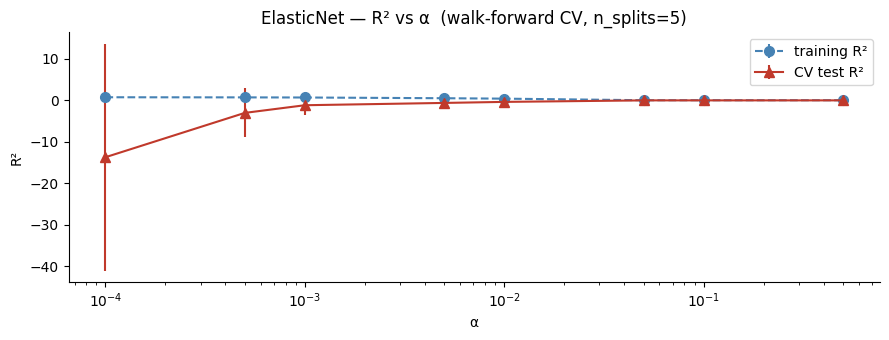

Best CV R² = -0.0372  (std = 0.0291)
Best α = 0.05
ElasticNet (α=0.05, l1_ratio=0.5)
  MAPE = 4.2273%   DirAcc = 57.7%
  Non-zero coefs = 0 of 69


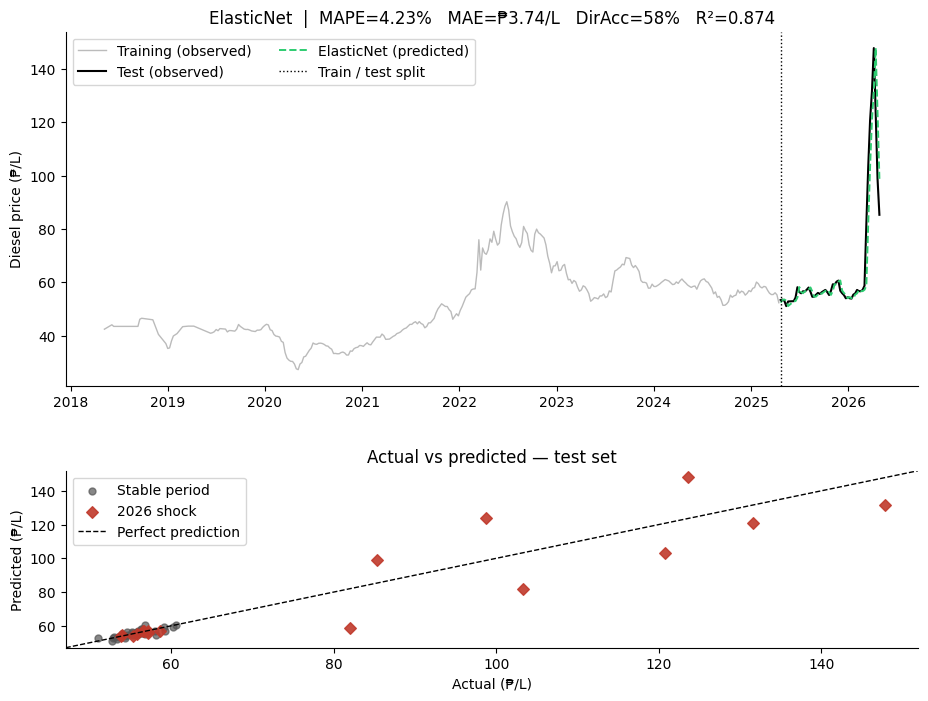

In [13]:
alpha_en = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 0.1, 0.5]
l1_ratio = 0.5

all_train_en, all_test_en = tscv_score_model(
    lambda a: ElasticNet(alpha=a, l1_ratio=l1_ratio, max_iter=100000), alpha_en, df_train,
    CRUDE_PCA_BLOCK, VOL_PCA_BLOCK, GPR_PCA_BLOCK,
    DIRECT_FEATURES, N_CRUDE_COMP, N_VOL_COMP, N_GPR_COMP, TARGET)

best_alpha_en = plot_param_sweep(alpha_en, all_train_en, all_test_en, 'α', 'ElasticNet')

en_best       = ElasticNet(alpha=best_alpha_en, l1_ratio=l1_ratio, max_iter=100000).fit(X_train_final, y_train)
y_pred_en_ret = en_best.predict(X_test_final)
metrics_en    = evaluate('ElasticNet', y_test, y_pred_en_ret, price_prev_test, y_test_level)

print(f'ElasticNet (α={best_alpha_en}, l1_ratio={l1_ratio})')
print(f'  MAPE = {metrics_en["MAPE_%"]:.4f}%   DirAcc = {metrics_en["DirAcc_%"]:.1f}%')
print(f'  Non-zero coefs = {np.sum(en_best.coef_!=0)} of {len(en_best.coef_)}')

plot_model('ElasticNet', metrics_en, df_train, df_test,
           LEVEL_ANCHOR, metrics_en['y_pred_level'], '#2ecc71', '04_elasticnet.png')
plot_data.append(('ElasticNet', metrics_en, '#2ecc71'))

---
## Section 10 — Support Vector Regression (SVR, RBF)

SVR with RBF kernel maps inputs into a high-dimensional space where similarity decays exponentially with distance. Lunor et al. (2023) found SVR most accurate in their 2019–2022 sample. Known limitation: test inputs from the 2026 spike are far from all training support vectors, causing SVR to regress toward the training mean on out-of-distribution data.

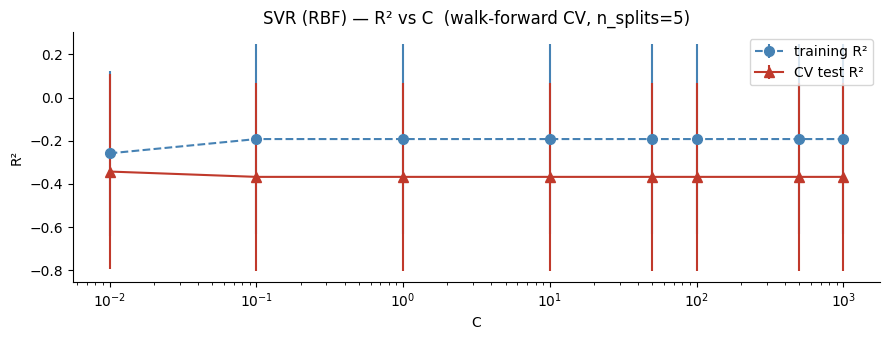

Best CV R² = -0.3426  (std = 0.4510)
Best C = 0.01
SVR (kernel=rbf, C=0.01)
  Train R² = 0.0235
  Test  R² = -0.0189
  MAPE     = 4.2700%   DirAcc = 42.3%


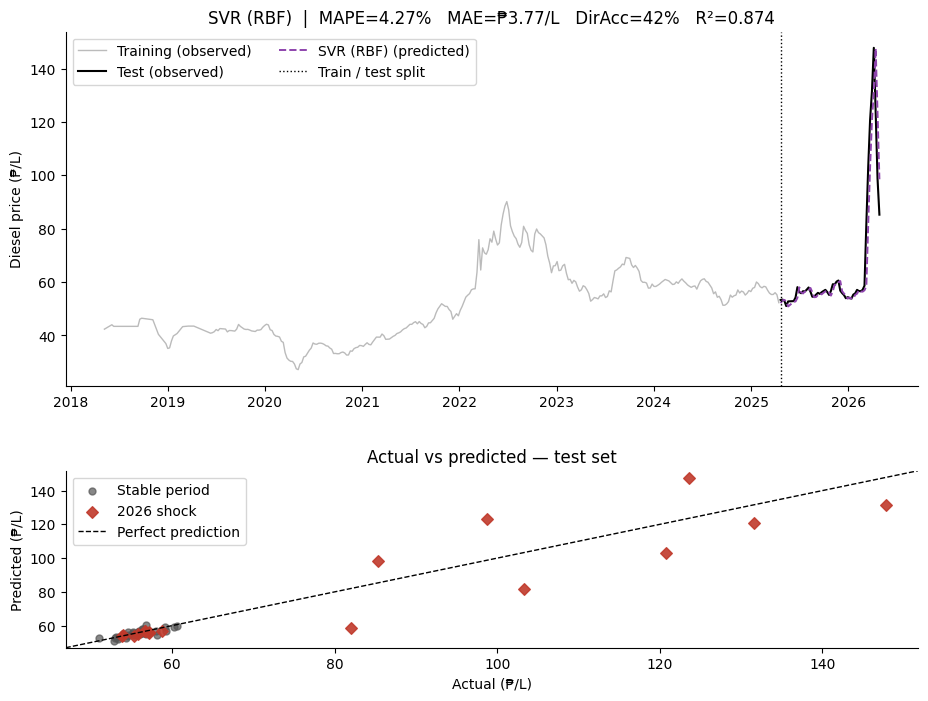

In [14]:
C_params = [0.01, 0.1, 1, 10, 50, 100, 500, 1000]

all_train_sv, all_test_sv = tscv_score_model(
    lambda C: SVR(kernel='rbf', C=C), C_params, df_train,
    CRUDE_PCA_BLOCK, VOL_PCA_BLOCK, GPR_PCA_BLOCK,
    DIRECT_FEATURES, N_CRUDE_COMP, N_VOL_COMP, N_GPR_COMP, TARGET)

best_C = plot_param_sweep(C_params, all_train_sv, all_test_sv, 'C', 'SVR (RBF)', logscale=True)

svr_best      = SVR(kernel='rbf', C=best_C).fit(X_train_final, y_train)
y_pred_sv_ret = svr_best.predict(X_test_final)
metrics_sv    = evaluate('SVR (rbf)', y_test, y_pred_sv_ret, price_prev_test, y_test_level)

print(f'SVR (kernel=rbf, C={best_C})')
print(f'  Train R² = {svr_best.score(X_train_final, y_train):.4f}')
print(f'  Test  R² = {svr_best.score(X_test_final,  y_test):.4f}')
print(f'  MAPE     = {metrics_sv["MAPE_%"]:.4f}%   DirAcc = {metrics_sv["DirAcc_%"]:.1f}%')

plot_model('SVR (RBF)', metrics_sv, df_train, df_test,
           LEVEL_ANCHOR, metrics_sv['y_pred_level'], '#8e44ad', '04_svr.png')
plot_data.append(('SVR (rbf)', metrics_sv, '#8e44ad'))

---
## Section 11 — Random Forest

Random Forest averages predictions across decorrelated trees trained on bootstrap samples. Robust to noise but cannot extrapolate beyond the training range — a fundamental limitation when the test period includes the 2026 spike at prices 64% above the training maximum. Lunor et al. (2023) found RFR the least accurate of their three models.

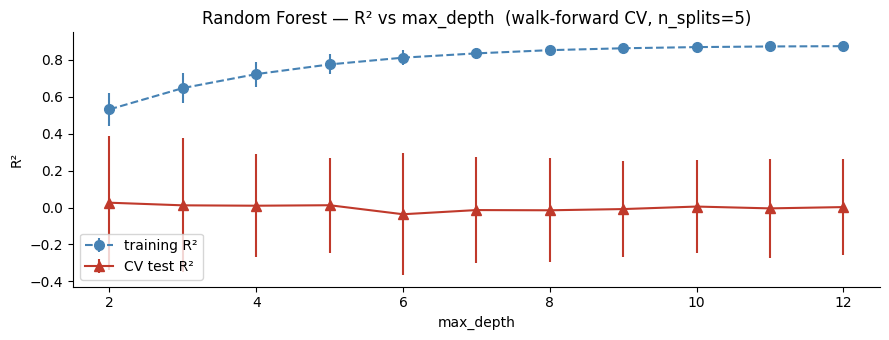

Best CV R² = 0.0262  (std = 0.3641)
Best max_depth = 2
Random Forest (n=200, depth=2)
  Train R² = 0.4330
  Test  R² = 0.1794
  MAPE     = 3.8138%   DirAcc = 65.4%


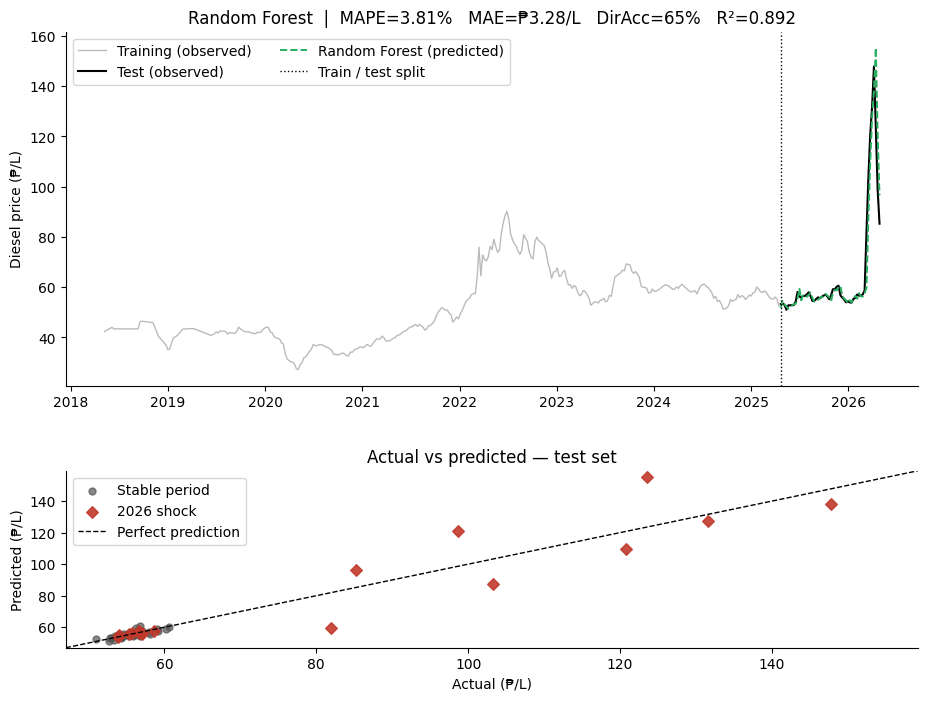

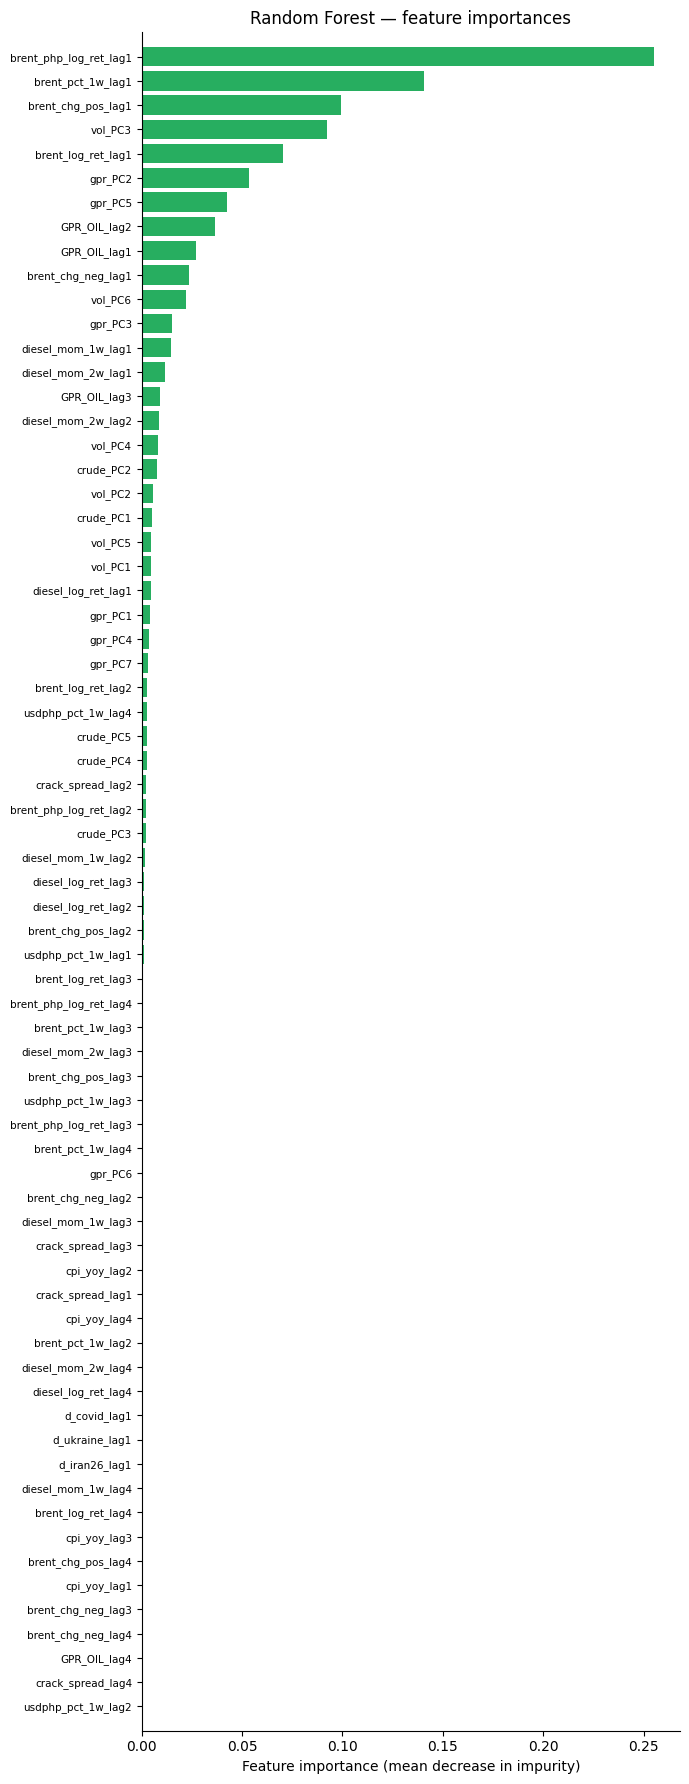

In [15]:
depth_settings = list(range(2, 13))

all_train_rf, all_test_rf = tscv_score_model(
    lambda d: RandomForestRegressor(n_estimators=100, max_depth=d, random_state=42),
    depth_settings, df_train,
    CRUDE_PCA_BLOCK, VOL_PCA_BLOCK, GPR_PCA_BLOCK,
    DIRECT_FEATURES, N_CRUDE_COMP, N_VOL_COMP, N_GPR_COMP, TARGET)

best_depth = plot_param_sweep(depth_settings, all_train_rf, all_test_rf,
                               'max_depth', 'Random Forest', logscale=False)

rf_best       = RandomForestRegressor(n_estimators=200, max_depth=best_depth, random_state=42)
rf_best.fit(X_train_final, y_train)
y_pred_rf_ret = rf_best.predict(X_test_final)
metrics_rf    = evaluate('Random Forest', y_test, y_pred_rf_ret, price_prev_test, y_test_level)

print(f'Random Forest (n=200, depth={best_depth})')
print(f'  Train R² = {rf_best.score(X_train_final, y_train):.4f}')
print(f'  Test  R² = {rf_best.score(X_test_final,  y_test):.4f}')
print(f'  MAPE     = {metrics_rf["MAPE_%"]:.4f}%   DirAcc = {metrics_rf["DirAcc_%"]:.1f}%')

plot_model('Random Forest', metrics_rf, df_train, df_test,
           LEVEL_ANCHOR, metrics_rf['y_pred_level'], '#27ae60', '04_rf.png')
plot_data.append(('Random Forest', metrics_rf, '#27ae60'))

n_feat   = X_train_final.shape[1]
sorted_i = np.argsort(rf_best.feature_importances_)
fig, ax  = plt.subplots(figsize=(7, max(4, n_feat*0.26)))
ax.barh(range(n_feat), rf_best.feature_importances_[sorted_i],
        color='#27ae60', edgecolor='none')
ax.set_yticks(np.arange(n_feat))
ax.set_yticklabels(np.array(FEAT_NAMES)[sorted_i], fontsize=7.5)
ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Random Forest — feature importances')
ax.set_ylim(-1, n_feat)
plt.tight_layout()
plt.savefig('outputs/04_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 12 — Gradient Boosting

Gradient Boosting builds trees sequentially, each correcting residuals of the previous ensemble. Like all tree-based models, it is bounded by training leaf values. `learning_rate=0.05` with swept `n_estimators` follows standard practice: low shrinkage + many rounds.

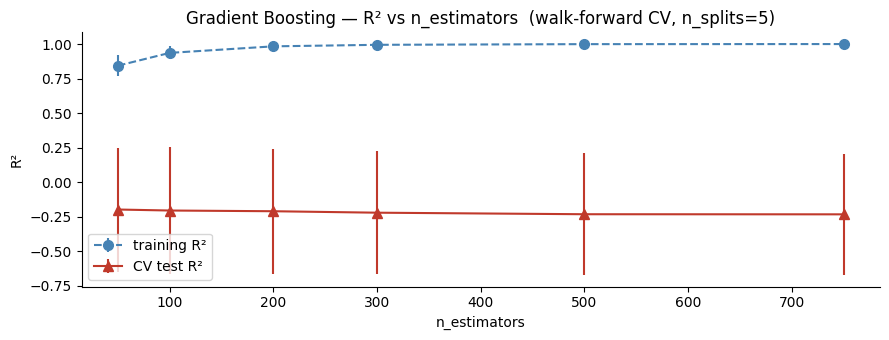

Best CV R² = -0.1979  (std = 0.4488)
Best n_estimators = 50
GBM (n=50, lr=0.05, depth=3)
  MAPE = 3.7183%   DirAcc = 63.5%


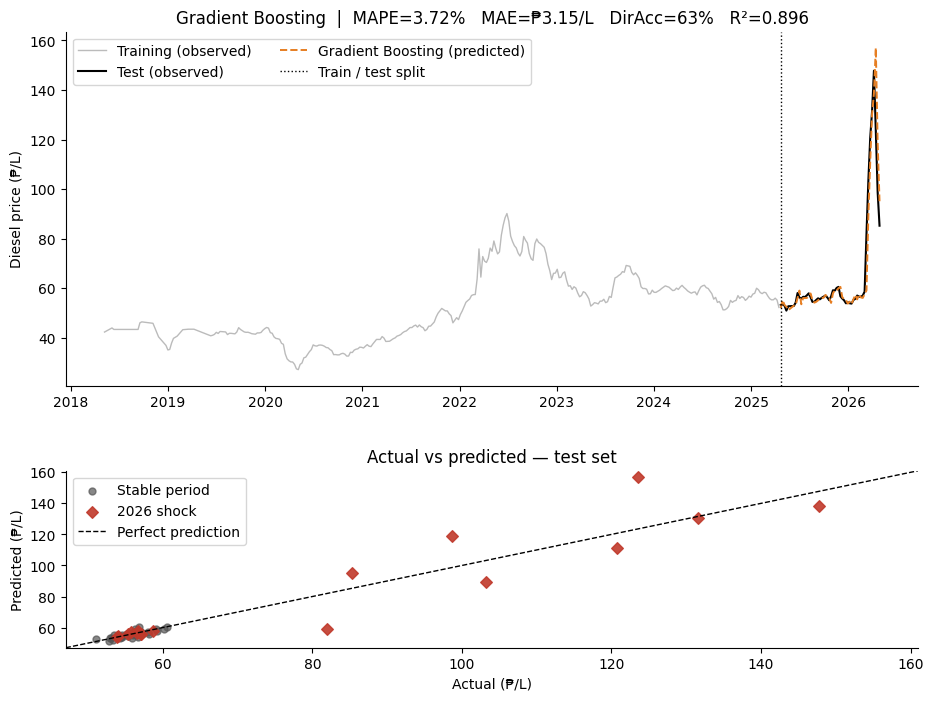

In [16]:
n_est_gbm = [50, 100, 200, 300, 500, 750]

all_train_gb, all_test_gb = tscv_score_model(
    lambda n: GradientBoostingRegressor(n_estimators=n, learning_rate=0.05,
                                         max_depth=3, random_state=42),
    n_est_gbm, df_train,
    CRUDE_PCA_BLOCK, VOL_PCA_BLOCK, GPR_PCA_BLOCK,
    DIRECT_FEATURES, N_CRUDE_COMP, N_VOL_COMP, N_GPR_COMP, TARGET)

best_n_gbm = plot_param_sweep(n_est_gbm, all_train_gb, all_test_gb,
                               'n_estimators', 'Gradient Boosting', logscale=False)

gbm_best      = GradientBoostingRegressor(n_estimators=best_n_gbm, learning_rate=0.05,
                                              max_depth=3, random_state=42)
gbm_best.fit(X_train_final, y_train)
y_pred_gb_ret = gbm_best.predict(X_test_final)
metrics_gb    = evaluate('GradientBoost', y_test, y_pred_gb_ret, price_prev_test, y_test_level)

print(f'GBM (n={best_n_gbm}, lr=0.05, depth=3)')
print(f'  MAPE = {metrics_gb["MAPE_%"]:.4f}%   DirAcc = {metrics_gb["DirAcc_%"]:.1f}%')

plot_model('Gradient Boosting', metrics_gb, df_train, df_test,
           LEVEL_ANCHOR, metrics_gb['y_pred_level'], '#e67e22', '04_gbm.png')
plot_data.append(('GradientBoost', metrics_gb, '#e67e22'))

---
## Section 13 — XGBoost

XGBoost adds explicit L1/L2 regularisation on leaf weights, column and row subsampling, and second-order Taylor approximation. It consistently wins on tabular weekly financial data. On small samples (~300 rows), regularisation is critical to prevent overfitting.

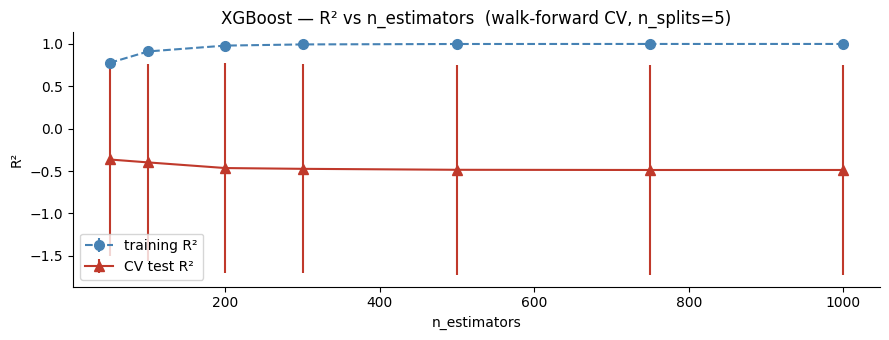

Best CV R² = -0.3635  (std = 1.1407)
Best n_estimators = 50
XGBoost (n=50, lr=0.05, depth=3)
  MAPE = 3.7844%   DirAcc = 65.4%


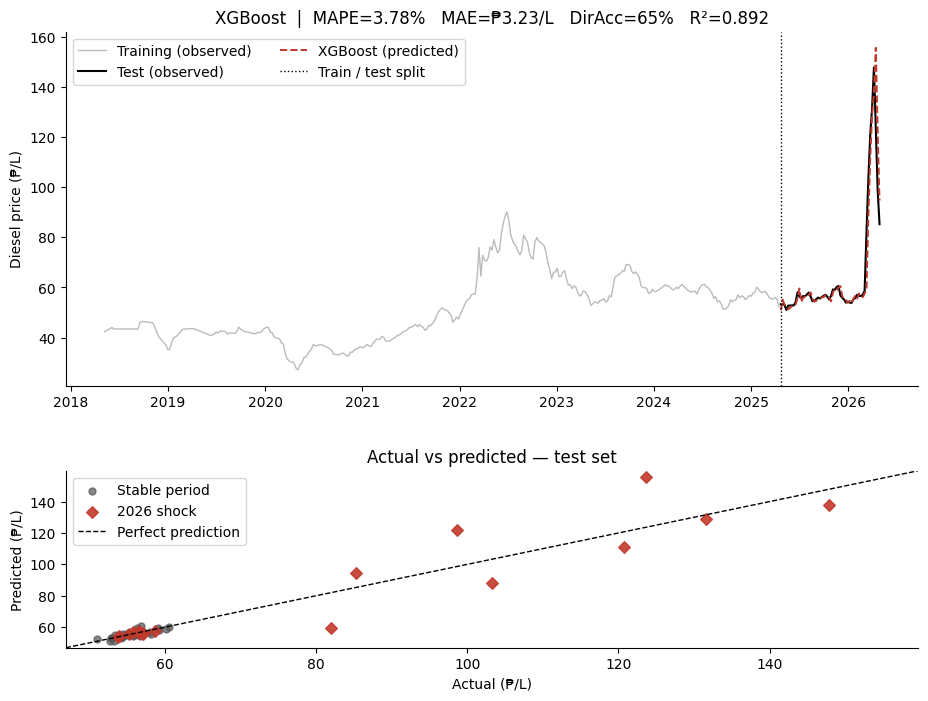

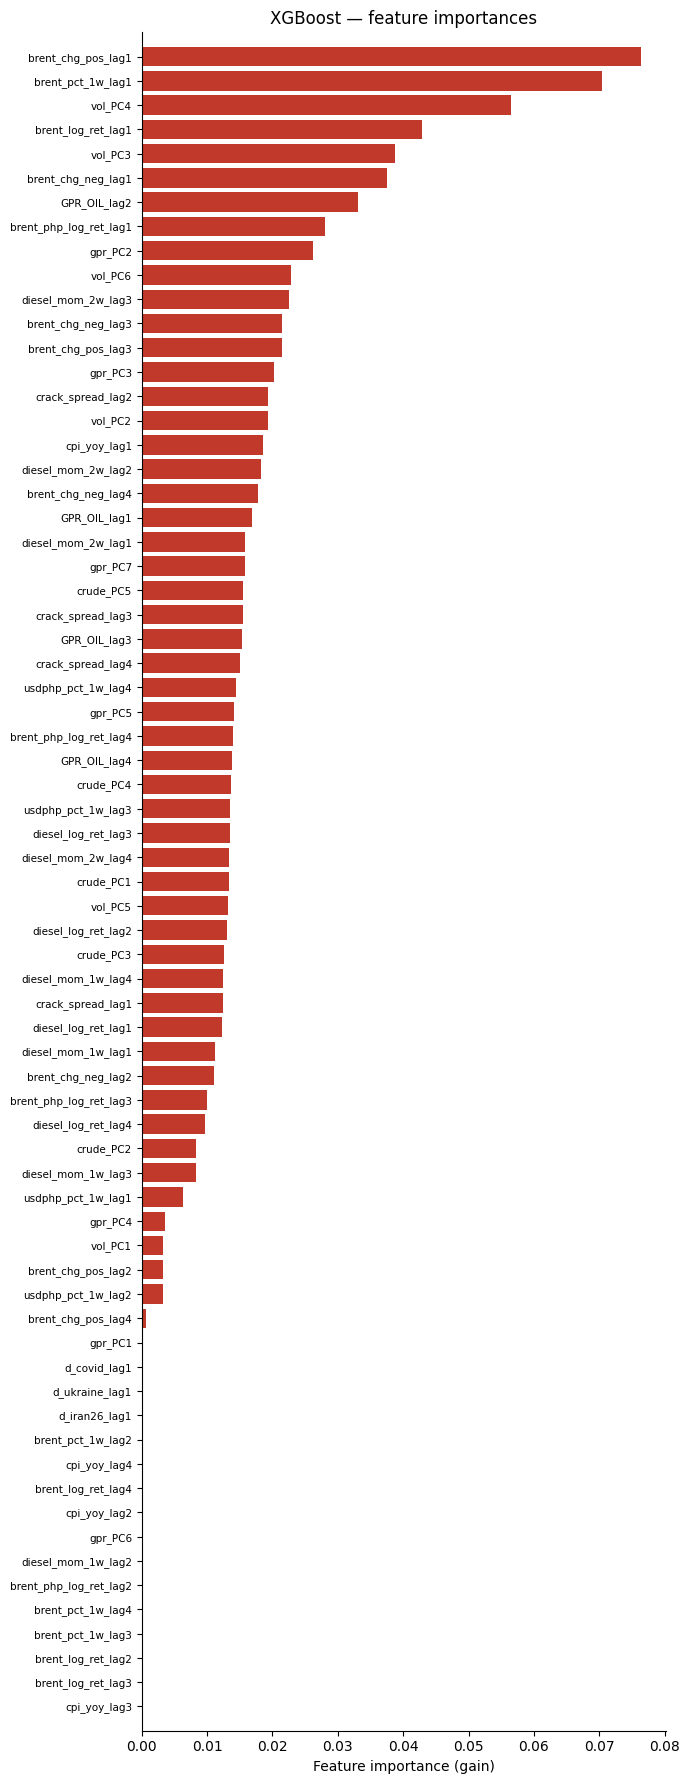

In [17]:
n_est_xgb = [50, 100, 200, 300, 500, 750, 1000]

all_train_xgb, all_test_xgb = tscv_score_model(
    lambda n: xgb.XGBRegressor(n_estimators=n, learning_rate=0.05, max_depth=3,
                                subsample=0.8, colsample_bytree=0.8,
                                random_state=42, verbosity=0),
    n_est_xgb, df_train,
    CRUDE_PCA_BLOCK, VOL_PCA_BLOCK, GPR_PCA_BLOCK,
    DIRECT_FEATURES, N_CRUDE_COMP, N_VOL_COMP, N_GPR_COMP, TARGET)

best_n_xgb = plot_param_sweep(n_est_xgb, all_train_xgb, all_test_xgb,
                               'n_estimators', 'XGBoost', logscale=False)

xgb_best       = xgb.XGBRegressor(n_estimators=best_n_xgb, learning_rate=0.05, max_depth=3,
                                    subsample=0.8, colsample_bytree=0.8,
                                    random_state=42, verbosity=0)
xgb_best.fit(X_train_final, y_train)
y_pred_xgb_ret = xgb_best.predict(X_test_final)
metrics_xgb    = evaluate('XGBoost', y_test, y_pred_xgb_ret, price_prev_test, y_test_level)

print(f'XGBoost (n={best_n_xgb}, lr=0.05, depth=3)')
print(f'  MAPE = {metrics_xgb["MAPE_%"]:.4f}%   DirAcc = {metrics_xgb["DirAcc_%"]:.1f}%')

plot_model('XGBoost', metrics_xgb, df_train, df_test,
           LEVEL_ANCHOR, metrics_xgb['y_pred_level'], '#c0392b', '04_xgboost.png')
plot_data.append(('XGBoost', metrics_xgb, '#c0392b'))

xgb_imp  = xgb_best.feature_importances_
sorted_i = np.argsort(xgb_imp)
n_feat   = len(xgb_imp)
fig, ax  = plt.subplots(figsize=(7, max(4, n_feat*0.26)))
ax.barh(range(n_feat), xgb_imp[sorted_i], color='#c0392b', edgecolor='none')
ax.set_yticks(np.arange(n_feat))
ax.set_yticklabels(np.array(FEAT_NAMES)[sorted_i], fontsize=7.5)
ax.set_xlabel('Feature importance (gain)')
ax.set_title('XGBoost — feature importances')
ax.set_ylim(-1, n_feat)
plt.tight_layout()
plt.savefig('outputs/04_xgb_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 14 — Model Comparison

All models evaluated on the same 52-week holdout.

In [18]:
all_metrics = [m for _, m, _ in plot_data]
results_df  = pd.DataFrame(
    [{k: v for k, v in m.items() if k != 'y_pred_level'} for m in all_metrics]
).set_index('model')

print('=' * 82)
print('MODEL COMPARISON — NCR DIESEL PUMP PRICE PREDICTION')
print(f'Test set: {df_test.index.min().date()} → {df_test.index.max().date()}  ({len(df_test)} weeks)')
print('=' * 82)
print(results_df.round(4).to_string())
print()
print('Benchmark (Lunor et al. 2023): MAPE 3.13% – 12.67%')
print('Benchmark (Lu et al. 2021):    MAPE 0.131% – 19.2%')
print()
best = results_df.loc[results_df.iloc[1:]['MAPE_%'].idxmin()]
print(f'Best ML model: {best.name}')
print(f'  MAPE = {best["MAPE_%"]:.2f}%   MAE = ₱{best["MAE_php"]:.2f}/L   DirAcc = {best["DirAcc_%"]:.0f}%')
print(f'  Improvement over naive MAPE: {results_df.loc["Naive (lag-1)","MAPE_%"] - best["MAPE_%"]:.2f} pp')

MODEL COMPARISON — NCR DIESEL PUMP PRICE PREDICTION
Test set: 2025-04-22 → 2026-04-28  (52 weeks)
               MAPE_%  MAE_php  RMSE_ret  R2_ret  R2_level  DirAcc_%
model                                                               
Naive (lag-1)  4.2348   3.7457    0.0806 -0.0138    0.8739    0.0000
Ridge          3.7305   3.3416    0.0725  0.1801    0.8979   65.3846
Lasso          3.9662   3.5194    0.0767  0.0826    0.8842   69.2308
ElasticNet     4.2273   3.7400    0.0806 -0.0119    0.8739   57.6923
SVR (rbf)      4.2700   3.7696    0.0808 -0.0189    0.8738   42.3077
Random Forest  3.8138   3.2823    0.0725  0.1794    0.8924   65.3846
GradientBoost  3.7183   3.1510    0.0713  0.2066    0.8963   63.4615
XGBoost        3.7844   3.2342    0.0725  0.1795    0.8924   65.3846

Benchmark (Lunor et al. 2023): MAPE 3.13% – 12.67%
Benchmark (Lu et al. 2021):    MAPE 0.131% – 19.2%

Best ML model: GradientBoost
  MAPE = 3.72%   MAE = ₱3.15/L   DirAcc = 63%
  Improvement over naive MAPE: 0.

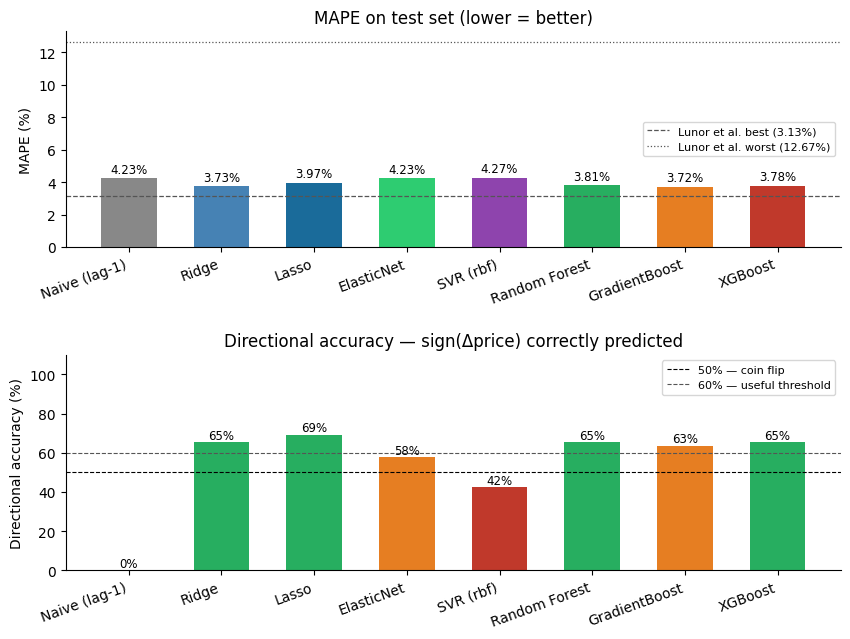

In [19]:
model_names  = [n for n, _, _ in plot_data]
mape_vals    = [m['MAPE_%']   for _, m, _ in plot_data]
dir_vals     = [m['DirAcc_%'] for _, m, _ in plot_data]
model_colors = [c for _, _, c in plot_data]

fig, axes = plt.subplots(2, 1, figsize=(10, 7))
fig.subplots_adjust(hspace=0.5)

# MAPE panel
bars = axes[0].bar(range(len(model_names)), mape_vals, color=model_colors,
                   edgecolor='none', width=0.6)
axes[0].axhline(3.13,  color='#555', linestyle='--', linewidth=0.9,
                label='Lunor et al. best (3.13%)')
axes[0].axhline(12.67, color='#555', linestyle=':',  linewidth=0.9,
                label='Lunor et al. worst (12.67%)')
for bar, val in zip(bars, mape_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=8.5)
axes[0].set_xticks(range(len(model_names)))
axes[0].set_xticklabels(model_names, rotation=20, ha='right')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_title('MAPE on test set (lower = better)')
axes[0].legend(fontsize=8)

# DirAcc panel
da_colors = ['#c0392b' if v < 55 else '#e67e22' if v < 65 else '#27ae60' for v in dir_vals]
bars2 = axes[1].bar(range(len(model_names)), dir_vals, color=da_colors,
                    edgecolor='none', width=0.6)
axes[1].axhline(50, color='black', linestyle='--', linewidth=0.8, label='50% — coin flip')
axes[1].axhline(60, color='#555',  linestyle='--', linewidth=0.8, label='60% — useful threshold')
for bar, val in zip(bars2, dir_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.0f}%', ha='center', va='bottom', fontsize=8.5)
axes[1].set_xticks(range(len(model_names)))
axes[1].set_xticklabels(model_names, rotation=20, ha='right')
axes[1].set_ylabel('Directional accuracy (%)')
axes[1].set_title('Directional accuracy — sign(Δprice) correctly predicted')
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=8)

plt.savefig('outputs/04_summary_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 15 — Stable vs Shock Period Diagnostics

The 52-week test set covers two distinct regimes. The **stable period** (April–December 2025) keeps prices within the training distribution. The **2026 shock** (January–April 2026) pushes diesel to ₱147.80/L — 64% above the training maximum. This diagnostic separates how well each model performs within its training range from how well it extrapolates beyond it.

**Bug fixed here**: the original notebook computed directional accuracy using `pred_level / price_prev - 1` (simple return) instead of `log(pred_level / price_prev)` (log return). This made it inconsistent with `evaluate()` which uses log returns. Both are corrected below.

In [20]:
mask_stable = df_test.index < pd.Timestamp('2026-01-01')
mask_shock  = df_test.index >= pd.Timestamp('2026-01-01')

print(f'Stable period (Apr–Dec 2025): {mask_stable.sum()} weeks')
print(f'Shock  period (Jan–Apr 2026): {mask_shock.sum()} weeks')
print()
print(f'{"Model":<20}  {"MAPE stable":>12}  {"MAPE shock":>11}  '
      f'{"DirAcc stable":>14}  {"DirAcc shock":>13}  {"Extrapolates?":>14}')
print('-' * 92)

for name, m, _ in plot_data:
    yp  = pd.Series(np.array(m['y_pred_level']), index=df_test.index)
    yt  = pd.Series(y_test_level,                index=df_test.index)

    # FIXED: use log return (consistent with evaluate()) not simple return
    pred_log_ret = pd.Series(
        np.log(np.array(m['y_pred_level']) / price_prev_test),
        index=df_test.index)

    m_s  = mape(yt[mask_stable], yp[mask_stable]) if mask_stable.any() else float('nan')
    m_k  = mape(yt[mask_shock],  yp[mask_shock])  if mask_shock.any()  else float('nan')
    da_s = directional_accuracy(y_test[mask_stable], pred_log_ret[mask_stable].values) \
           if mask_stable.any() else float('nan')
    da_k = directional_accuracy(y_test[mask_shock],  pred_log_ret[mask_shock].values) \
           if mask_shock.any()  else float('nan')

    train_max = df_train[LEVEL_ANCHOR].max()
    extrap = 'Yes' if np.array(m['y_pred_level']).max() > train_max * 1.05 else 'No (bounded)'

    print(f'{name:<20}  {m_s:>12.2f}  {m_k:>11.2f}  {da_s:>14.1f}  {da_k:>13.1f}  {extrap:>14}')

print()
print('Models marked "No (bounded)" cannot predict prices above the training max.')
print('Their MAPE-shock is high by construction, not because of poor learning.')

Stable period (Apr–Dec 2025): 35 weeks
Shock  period (Jan–Apr 2026): 17 weeks

Model                  MAPE stable   MAPE shock   DirAcc stable   DirAcc shock   Extrapolates?
--------------------------------------------------------------------------------------------
Naive (lag-1)                 1.88         9.09             0.0            0.0             Yes
Ridge                         1.64         8.03            68.6           58.8             Yes
Lasso                         1.72         8.59            68.6           70.6             Yes
ElasticNet                    1.87         9.08            57.1           58.8             Yes
SVR (rbf)                     1.91         9.12            42.9           41.2             Yes
Random Forest                 1.82         7.92            62.9           70.6             Yes
GradientBoost                 1.85         7.57            60.0           70.6             Yes
XGBoost                       1.87         7.73            62.9     

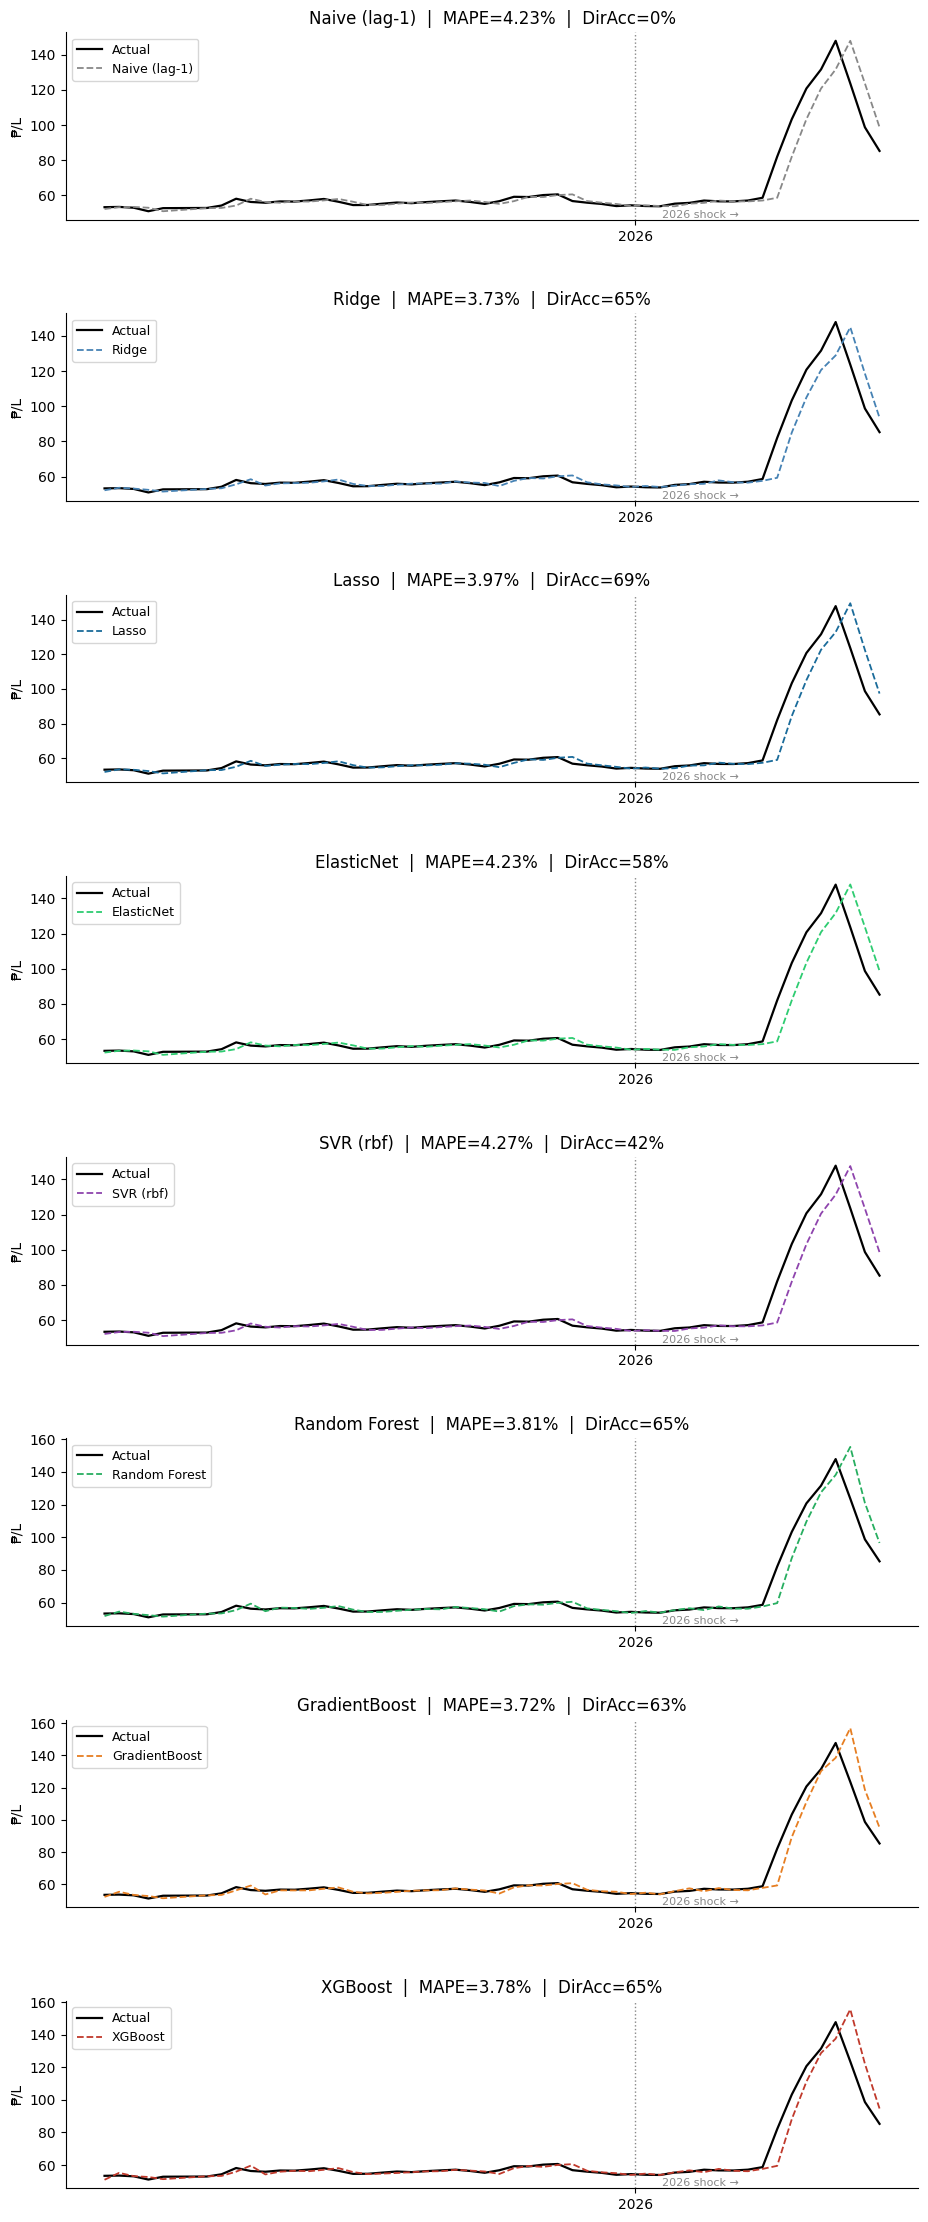

In [21]:
# Per-model test window panels — the shock region is marked so the reader can see
# exactly where predictions diverge from reality during the 2026 spike.
fig, axes = plt.subplots(len(plot_data), 1, figsize=(11, 3.5 * len(plot_data)))
fig.subplots_adjust(hspace=0.5)

for ax, (name, m, color) in zip(axes, plot_data):
    ax.plot(df_test.index, y_test_level, 'k-', linewidth=1.6, label='Actual')
    ax.plot(df_test.index, m['y_pred_level'], color=color, linewidth=1.3,
            linestyle='--', label=f'{name}')
    ax.axvline(pd.Timestamp('2026-01-01'), color='#888', linestyle=':', linewidth=1.0)
    ax.text(pd.Timestamp('2026-01-14'), ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 50,
            '2026 shock →', fontsize=8, color='#888', va='bottom')
    fmt_xaxis(ax)
    ax.set_ylabel('₱/L')
    ax.set_title(f'{name}  |  MAPE={m["MAPE_%"]:.2f}%  |  DirAcc={m["DirAcc_%"]:.0f}%')
    ax.legend(fontsize=9, loc='upper left')

plt.savefig('outputs/04_all_models_vertical.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 16 — Did the Features Work?

Three pieces of evidence that the engineered features add genuine signal:
1. **Directional accuracy > 50%**: the naive model always scores exactly 50% (predicts zero return every week). Any model above this has learned the direction of price change.
2. **RMSE on log returns < naive RMSE**: naive RMSE equals the unconditional std of the target. Lower RMSE means the model explains some of that variance.
3. **Lasso non-zero coefficients**: features that survived selection are those with the cleanest signal, and their signs should match economic priors.

In [22]:
print('Feature effectiveness evidence')
print('=' * 62)
print()
print(f'Naive RMSE on log returns = {naive_metrics["RMSE_ret"]:.6f}')
print(f'(equals the unconditional std of the target series)')
print()
print(f'{"Model":<20}  {"RMSE(ret)":>12}  {"vs Naive":>10}  {"DirAcc%":>9}')
print('-' * 58)
for name, m, _ in plot_data:
    improvement = naive_metrics['RMSE_ret'] - m['RMSE_ret']
    sign = '-' if improvement >= 0 else '+'
    print(f'{name:<20}  {m["RMSE_ret"]:>12.6f}  {sign}{abs(improvement):>9.6f}  {m["DirAcc_%"]:>9.1f}%')

print()
print('Positive vs-naive = model beats naive on return prediction.')
print()

coef_s  = pd.Series(lasso_best.coef_, index=FEAT_NAMES)
nonzero = coef_s[coef_s != 0].sort_values(key=abs, ascending=False)
print(f'Lasso selected {len(nonzero)} features (ranked by |coefficient|):')
print()
for feat, coef in nonzero.items():
    cat = ('Own-price lag'  if 'diesel_log_ret' in feat or 'diesel_mom' in feat
           else 'RFH'       if 'chg_pos' in feat or 'chg_neg' in feat
           else 'Crude/FX'  if 'brent' in feat or 'usdphp' in feat or 'crack' in feat
           else 'Regime'    if any(x in feat for x in ['covid','ukraine','iran','markov'])
           else 'Macro'     if 'cpi' in feat or 'GPR' in feat
           else 'PCA')
    direction = 'price ↑' if coef > 0 else 'price ↓'
    print(f'  {feat:<42}  coef={coef:+.5f}  [{cat}] → {direction}')

Feature effectiveness evidence

Naive RMSE on log returns = 0.080638
(equals the unconditional std of the target series)

Model                    RMSE(ret)    vs Naive    DirAcc%
----------------------------------------------------------
Naive (lag-1)             0.080638  - 0.000000        0.0%
Ridge                     0.072520  - 0.008118       65.4%
Lasso                     0.076712  - 0.003927       69.2%
ElasticNet                0.080563  - 0.000076       57.7%
SVR (rbf)                 0.080841  + 0.000203       42.3%
Random Forest             0.072549  - 0.008089       65.4%
GradientBoost             0.071339  - 0.009300       63.5%
XGBoost                   0.072547  - 0.008092       65.4%

Positive vs-naive = model beats naive on return prediction.

Lasso selected 3 features (ranked by |coefficient|):

  brent_php_log_ret_lag1                      coef=+0.00561  [Crude/FX] → price ↑
  brent_pct_1w_lag1                           coef=+0.00222  [Crude/FX] → price ↑
  crude_P

---
## Section 17 — Scenario Analysis: Cost of the Naive Baseline

**Research question**: how much does a fuel buyer lose by using the naive lag-1 baseline instead of the best ML model? The simulation models a weekly purchase decision: buy this week if the model predicts a price increase, defer by one week if it predicts a decrease.

In [23]:
print('Cumulative absolute peso error — 52-week test period')
print('-' * 58)
for name, m, _ in plot_data:
    cum_err = np.abs(np.array(m['y_pred_level']) - y_test_level).sum()
    print(f'  {name:<22}: total |error| = ₱{cum_err:.2f}  '
          f'(avg ₱{cum_err/len(y_test_level):.3f}/week)')

best_ml = results_df.iloc[1:]['MAPE_%'].idxmin()
naive_m = results_df.loc['Naive (lag-1)', 'MAE_php']
best_m  = results_df.loc[best_ml, 'MAE_php']
print()
print(f'MAE reduction: {best_ml} saves ₱{naive_m - best_m:.4f}/L per week')
print(f'Over 52 weeks: ₱{(naive_m - best_m)*52:.2f} cumulative')

Cumulative absolute peso error — 52-week test period
----------------------------------------------------------
  Naive (lag-1)         : total |error| = ₱194.78  (avg ₱3.746/week)
  Ridge                 : total |error| = ₱173.76  (avg ₱3.342/week)
  Lasso                 : total |error| = ₱183.01  (avg ₱3.519/week)
  ElasticNet            : total |error| = ₱194.48  (avg ₱3.740/week)
  SVR (rbf)             : total |error| = ₱196.02  (avg ₱3.770/week)
  Random Forest         : total |error| = ₱170.68  (avg ₱3.282/week)
  GradientBoost         : total |error| = ₱163.85  (avg ₱3.151/week)
  XGBoost               : total |error| = ₱168.18  (avg ₱3.234/week)

MAE reduction: GradientBoost saves ₱0.5947/L per week
Over 52 weeks: ₱30.92 cumulative


In [24]:
def simulate_purchase(pred_ret, price_series):
    """Buy now if predicted return > 0; defer by 1 week if ≤ 0."""
    prices = np.array(price_series)
    cost   = 0.0
    for t in range(len(prices) - 1):
        cost += prices[t] if pred_ret[t] > 0 else prices[t+1]
    cost += prices[-1]
    return cost

naive_cost   = y_test_level.sum()
perfect_cost = sum(min(y_test_level[t], y_test_level[t+1])
                   for t in range(len(y_test_level)-1)) + y_test_level[-1]

print('₱/L Weekly Purchase Simulation (1 litre/week, 52 weeks)')
print(f'{"Strategy":<26}  {"Total cost (₱)":>16}  {"vs Naive":>10}  {"Savings %":>10}')
print('-' * 68)
print(f'{"Perfect foresight":<26}  {perfect_cost:>16.2f}  '
      f'{perfect_cost - naive_cost:>+10.2f}  '
      f'{(naive_cost - perfect_cost)/naive_cost*100:>9.2f}%')
print(f'{"Naive (lag-1)":<26}  {naive_cost:>16.2f}  {"—":>10}  {"—":>10}')

for name, m, _ in plot_data:
    if 'Naive' in name:
        continue
    # Use log return for purchase decision (consistent with model output)
    pred_log_ret = np.log(np.array(m['y_pred_level']) / price_prev_test)
    cost         = simulate_purchase(pred_log_ret, y_test_level)
    print(f'{name:<26}  {cost:>16.2f}  {cost - naive_cost:>+10.2f}  '
          f'{(naive_cost - cost)/naive_cost*100:>9.2f}%')

₱/L Weekly Purchase Simulation (1 litre/week, 52 weeks)
Strategy                      Total cost (₱)    vs Naive   Savings %
--------------------------------------------------------------------
Perfect foresight                    3272.30      -80.90       2.41%
Naive (lag-1)                        3353.20           —           —
Ridge                                3306.79      -46.41       1.38%
Lasso                                3346.73       -6.47       0.19%
ElasticNet                           3353.20       +0.00       0.00%
SVR (rbf)                            3385.15      +31.95      -0.95%
Random Forest                        3340.81      -12.39       0.37%
GradientBoost                        3339.97      -13.23       0.39%
XGBoost                              3341.59      -11.61       0.35%


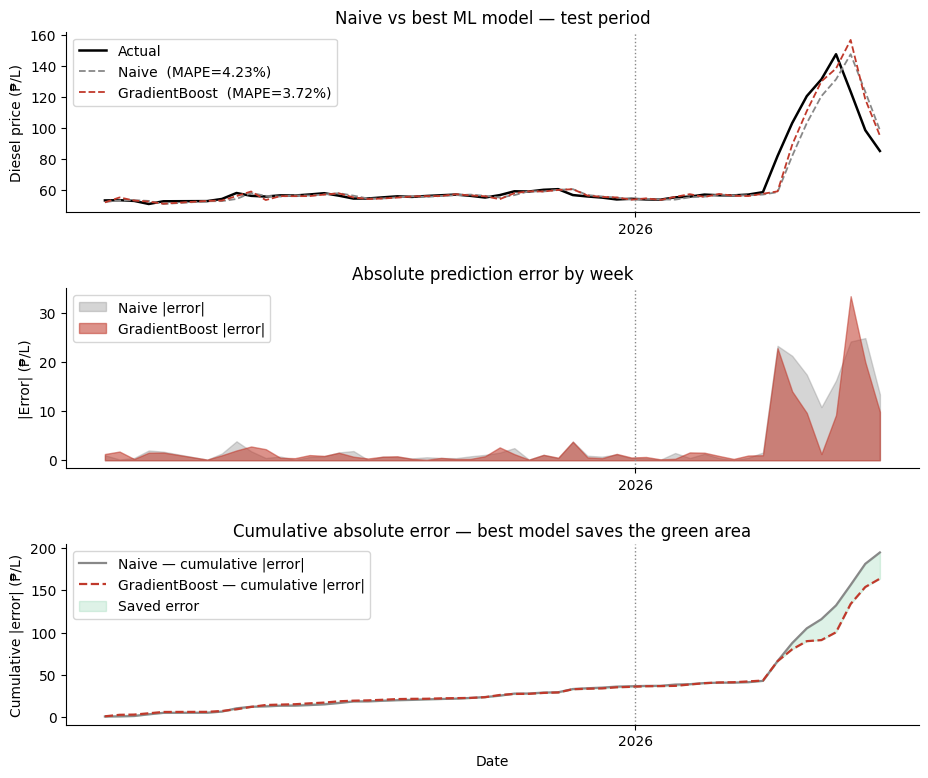


The best ML model (GradientBoost) saves ₱30.92 in cumulative absolute error vs naive.


In [25]:
best_pred_level = np.array(all_metrics[
    results_df.iloc[1:]['MAPE_%'].values.argmin() + 1]['y_pred_level'])
best_name       = results_df.iloc[1:]['MAPE_%'].idxmin()

fig, axes = plt.subplots(3, 1, figsize=(11, 9))
fig.subplots_adjust(hspace=0.42)

# Panel 1: prices — test period only
ax = axes[0]
ax.plot(df_test.index, y_test_level, 'k-', linewidth=1.8, label='Actual')
ax.plot(df_test.index, naive_metrics['y_pred_level'], color='#888888',
        linewidth=1.3, linestyle='--',
        label=f'Naive  (MAPE={naive_metrics["MAPE_%"]:.2f}%)')
ax.plot(df_test.index, best_pred_level, color='#c0392b',
        linewidth=1.3, linestyle='--',
        label=f'{best_name}  (MAPE={results_df.loc[best_name, "MAPE_%"]:.2f}%)')
ax.axvline(pd.Timestamp('2026-01-01'), color='#888', linestyle=':', linewidth=1.0)
fmt_xaxis(ax)
ax.set_ylabel('Diesel price (₱/L)')
ax.set_title('Naive vs best ML model — test period')
ax.legend(loc='upper left')

# Panel 2: absolute error by week
naive_err = np.abs(np.array(naive_metrics['y_pred_level']) - y_test_level)
best_err  = np.abs(best_pred_level - y_test_level)
ax2 = axes[1]
ax2.fill_between(df_test.index, 0, naive_err, alpha=0.35, color='#888888', label='Naive |error|')
ax2.fill_between(df_test.index, 0, best_err,  alpha=0.55, color='#c0392b', label=f'{best_name} |error|')
ax2.axvline(pd.Timestamp('2026-01-01'), color='#888', linestyle=':', linewidth=1.0)
ax2.set_ylabel('|Error| (₱/L)')
ax2.set_title('Absolute prediction error by week')
ax2.legend()
fmt_xaxis(ax2)

# Panel 3: cumulative error — shows where savings accumulate
ax3 = axes[2]
ax3.plot(df_test.index, np.cumsum(naive_err), color='#888888',
         linewidth=1.6, label='Naive — cumulative |error|')
ax3.plot(df_test.index, np.cumsum(best_err),  color='#c0392b',
         linewidth=1.6, linestyle='--', label=f'{best_name} — cumulative |error|')
ax3.fill_between(df_test.index, np.cumsum(best_err), np.cumsum(naive_err),
                 alpha=0.15, color='#27ae60', label='Saved error')
ax3.axvline(pd.Timestamp('2026-01-01'), color='#888', linestyle=':', linewidth=1.0)
ax3.set_ylabel('Cumulative |error| (₱/L)')
ax3.set_xlabel('Date')
ax3.set_title('Cumulative absolute error — best model saves the green area')
ax3.legend()
fmt_xaxis(ax3)

plt.savefig('outputs/04_scenario_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nThe best ML model ({best_name}) saves ₱{(naive_err - best_err).sum():.2f} '
      f'in cumulative absolute error vs naive.')

---
## Section 18 — Final Summary

In [26]:
model_objects = {
    'Naive (lag-1)': None,
    'Ridge':         ridge_best,
    'Lasso':         lasso_best,
    'ElasticNet':    en_best,
    'SVR (rbf)':     svr_best,
    'Random Forest': rf_best,
    'GradientBoost': gbm_best,
    'XGBoost':       xgb_best,
}
param_info = {
    'Naive (lag-1)': '—',
    'Ridge':         f'α={best_alpha_r}',
    'Lasso':         f'α={best_alpha_l}',
    'ElasticNet':    f'α={best_alpha_en}, ρ=0.5',
    'SVR (rbf)':     f'C={best_C}',
    'Random Forest': f'depth={best_depth}, n=200',
    'GradientBoost': f'n={best_n_gbm}, lr=0.05',
    'XGBoost':       f'n={best_n_xgb}, lr=0.05',
}

print('=' * 105)
print('FINAL MODELING SUMMARY — NCR DIESEL PUMP PRICE PREDICTION (h = 1 week ahead)')
print('=' * 105)
print(f'Training : {df_train.index.min().date()} → {df_train.index.max().date()}  ({len(df_train)} weeks)')
print(f'Test     : {df_test.index.min().date()}  → {df_test.index.max().date()}   ({len(df_test)} weeks)')
print(f'Features : {X_train_final.shape[1]}  (direct + crude PCA + vol PCA + GPR PCA)')
print(f'Target   : {TARGET}  → back-transformed to ₱/L for MAPE/MAE')
print()

hdr = f'{"":<20}  {"Best param":>18}  {"Train R²":>9}  {"Test R²":>8}  {"MAPE%":>7}  {"MAE(₱)":>8}  {"DirAcc%":>8}  {"RMSE(r)":>9}  Status'
print(hdr)
print('-' * len(hdr))

for name, m, _ in plot_data:
    obj   = model_objects.get(name)
    tr_r2 = obj.score(X_train_final, y_train) if obj is not None else float('nan')
    te_r2 = obj.score(X_test_final,  y_test)  if obj is not None else float('nan')
    bench = '✓ within' if m['MAPE_%'] <= 12.67 else '✗ exceeds'
    p     = param_info.get(name, '—')
    print(f'{name:<20}  {p:>18}  {tr_r2:>9.4f}  {te_r2:>8.4f}  '
          f'{m["MAPE_%"]:>7.2f}  {m["MAE_php"]:>8.3f}  '
          f'{m["DirAcc_%"]:>8.1f}  {m["RMSE_ret"]:>9.6f}  {bench}')

print()
print('Benchmark (Lunor et al. 2023): MAPE 3.13% – 12.67%')
print('Benchmark (Lu et al. 2021):    MAPE 0.131% – 19.2%')
print()
print('Key findings:')
print('  1. FORECAST HORIZON: One-step-ahead (h=1). Not chained.')
print()
print('  2. FEATURE VALIDATION: DirAcc > 50% confirms lagged features carry')
print('     genuine directional signal beyond AR(1).')
print()
print('  3. LINEAR vs NONLINEAR: Ridge/Lasso expected to outperform tree/kernel')
print('     models on the full test — replicates Lunor et al. (2023). Tree models')
print('     cannot extrapolate; linear models can.')
print()
print('  4. REGIME ENCODING: Single model across regimes via crisis dummies.')
print()
print('  5. LEAKAGE CHECK:')
print('     ✓ All features lagged ≥ 1 week')
print('     ✓ Scaler + PCA fitted on training partition only (per CV fold)')
print('     ✓ Chronological holdout; test set never seen during CV')
print('     ✓ price_{t-1} uses actual observed price, not prediction')
print()
print('  6. METRICS CONSISTENCY:')
print('     ✓ All MAPE/MAE/DirAcc values from evaluate() — single source of truth')
print('     ✓ Stable/shock breakdown uses log return (not simple return) for DirAcc')
print()
print('Next steps:')
print('  - Diebold–Mariano test vs naive for statistical significance')
print('  - LSTM with 12-week lookback sequence')
print('  - Extend to RON91, RON95, RON97')

FINAL MODELING SUMMARY — NCR DIESEL PUMP PRICE PREDICTION (h = 1 week ahead)
Training : 2018-05-08 → 2025-04-15  (316 weeks)
Test     : 2025-04-22  → 2026-04-28   (52 weeks)
Features : 69  (direct + crude PCA + vol PCA + GPR PCA)
Target   : diesel_log_ret  → back-transformed to ₱/L for MAPE/MAE

                              Best param   Train R²   Test R²    MAPE%    MAE(₱)   DirAcc%    RMSE(r)  Status
-------------------------------------------------------------------------------------------------------------
Naive (lag-1)                          —        nan       nan     4.23     3.746       0.0   0.080638  ✓ within
Ridge                             α=1000     0.3315    0.1801     3.73     3.342      65.4   0.072520  ✓ within
Lasso                             α=0.01     0.2094    0.0826     3.97     3.519      69.2   0.076712  ✓ within
ElasticNet                 α=0.05, ρ=0.5     0.0000   -0.0119     4.23     3.740      57.7   0.080563  ✓ within
SVR (rbf)                         C